## Data preparation

In [1]:
import torch, platform, os, sys
print("Python:", sys.version)
print("Platform:", platform.platform())
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("CUDA device:", torch.cuda.get_device_name(0))
    print("CUDA capability:", torch.cuda.get_device_capability(0))
    print("Driver mem (free/total GB):", [x/1024**3 for x in torch.cuda.mem_get_info()])

import gc
torch.cuda.empty_cache()
gc.collect()

print("Memory before loading:")
print(f"GPU memory free: {(torch.cuda.get_device_properties(0).total_memory - torch.cuda.memory_reserved(0)) / 1e9:.1f} GB")

Python: 3.12.9 | packaged by conda-forge | (main, Mar  4 2025, 22:48:41) [GCC 13.3.0]
Platform: Linux-4.18.0-553.45.1.el8_10.x86_64-x86_64-with-glibc2.28
Torch: 2.5.1+cu121
CUDA available: True
CUDA device: NVIDIA A100-SXM4-80GB
CUDA capability: (8, 0)
Driver mem (free/total GB): [78.83935546875, 79.253662109375]
Memory before loading:
GPU memory free: 85.1 GB


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from aurora import Aurora, Batch, Metadata, rollout

print("Aurora AR Analysis Setup")
print("CUDA available:", torch.cuda.is_available())

# Load Aurora model (official way)
model = Aurora(use_lora=False)  # The pretrained version does not use LoRA.
model.load_checkpoint("microsoft/aurora", "aurora-0.25-pretrained.ckpt")

model.eval()
model = model.to("cuda")
print("✅ Aurora model loaded")

Aurora AR Analysis Setup
CUDA available: True
✅ Aurora model loaded


In [3]:
# Check what data Aurora needs and what it can provide
print("Aurora model variables:")
print("Surface vars:", model.surf_vars)
print("Atmospheric vars:", model.atmos_vars)

Aurora model variables:
Surface vars: ('2t', '10u', '10v', 'msl')
Atmospheric vars: ('z', 'u', 'v', 't', 'q')


In [4]:
import xarray as xr
from pathlib import Path
import pandas as pd

# Setup data paths following official Aurora format
download_path = Path("/scratch/moyanliu/Aurora Model/data/era5_batch")

static_file = download_path / "static.nc"
# Use glob patterns to select all matching files
surf_files = sorted(download_path.glob("2022-*-*-surface-level.nc"))
atmos_files = sorted(download_path.glob("2022-*-*-atmospheric.nc"))

print("📂 Loading ERA5 data files...")
print(f"  Static: {static_file}")
print(f"📂 Found {len(surf_files)} surface files")
print(f"📂 Found {len(atmos_files)} atmospheric files")

📂 Loading ERA5 data files...
  Static: /scratch/moyanliu/Aurora Model/data/era5_batch/static.nc
📂 Found 7 surface files
📂 Found 7 atmospheric files


In [5]:
start_date = "2022-12-22"
end_date   = "2022-12-28"
dates = pd.date_range(start=start_date, end=end_date, freq="D")

# Load datasets using official Aurora format
static_vars_ds = xr.open_dataset(static_file, engine="netcdf4")
surf_files = [download_path / f"{d.strftime('%Y-%m-%d')}-surface-level.nc" for d in dates]
atmos_files = [download_path / f"{d.strftime('%Y-%m-%d')}-atmospheric.nc" for d in dates]

# print("✅ Datasets loaded successfully!")
# print(f"\nStatic variables: {list(static_vars_ds.data_vars.keys())}")
# print(f"Surface variables: {list(surf_vars_ds.data_vars.keys())}")
# print(f"Atmospheric variables: {list(atmos_vars_ds.data_vars.keys())}")
# print(f"\nDimensions:")
# print(f"  Surface: {dict(surf_vars_ds.sizes)}")
# print(f"  Atmospheric: {dict(atmos_vars_ds.sizes)}")
# print(f"  Pressure levels: {atmos_vars_ds.pressure_level.values}")

# # Store for later validation use
# surf_vars_ds_full = surf_vars_ds
# atmos_vars_ds_full = atmos_vars_ds

In [6]:
static_vars_ds = xr.open_dataset(static_file, engine="netcdf4")

# Open multiple files together
surf_vars_ds = xr.open_mfdataset(
    surf_files,
    combine="by_coords",
    engine="netcdf4"
)
atmos_vars_ds = xr.open_mfdataset(
    atmos_files,
    combine="by_coords",
    engine="netcdf4"
)

print("✅ Combined datasets successfully!")
print(f"Surface dimensions: {dict(surf_vars_ds.sizes)}")
print(f"Atmospheric dimensions: {dict(atmos_vars_ds.sizes)}")

# Store for later validation use
surf_vars_ds_full = surf_vars_ds
atmos_vars_ds_full = atmos_vars_ds

✅ Combined datasets successfully!
Surface dimensions: {'valid_time': 28, 'latitude': 721, 'longitude': 1440}
Atmospheric dimensions: {'valid_time': 28, 'pressure_level': 13, 'latitude': 721, 'longitude': 1440}


In [7]:
# Calculate IVT for Atmospheric River Detection
def calculate_ivt_integrated(u_data, v_data, q_data, pressure_levels):
    """
    Calculate Integrated Water Vapor Transport using vertical integration
    
    IVT = (1/g) ∫ q*V dp
    
    Args:
        u_data: u-wind component 
                [levels, lat, lon] or 
                [batch, levels, lat, lon] or 
                [batch, time, levels, lat, lon]
        v_data: v-wind component (same shape as u_data)
        q_data: specific humidity (same shape as u_data)
        pressure_levels: pressure levels in hPa (tuple or tensor)
    
    Returns:
        ivt_u, ivt_v, ivt_magnitude in kg/(m·s)
    """
    g = 9.81  # m/s²
    
    # Convert pressure levels to tensor if needed
    if isinstance(pressure_levels, tuple):
        pressure_levels = torch.tensor(pressure_levels, dtype=torch.float32, device=u_data.device)
    
    # Convert pressure levels to Pa
    pressure_levels_pa = pressure_levels * 100  # hPa to Pa
    
    # Handle different input shapes
    if len(u_data.shape) == 3:  # [levels, lat, lon]
        n_levels = u_data.shape[0]
        reshape_back = None
        dp_shape = (n_levels, 1, 1)
        sum_dim = 0
        
    elif len(u_data.shape) == 4:  # [batch, levels, lat, lon]
        n_levels = u_data.shape[1]
        reshape_back = None
        dp_shape = (1, n_levels, 1, 1)
        sum_dim = 1
        
    elif len(u_data.shape) == 5:  # [batch, time, levels, lat, lon]
        n_levels = u_data.shape[2]
        orig_shape = u_data.shape
        # Flatten batch and time for processing
        u_data = u_data.reshape(-1, *u_data.shape[2:])  # [batch*time, levels, lat, lon]
        v_data = v_data.reshape(-1, *v_data.shape[2:])
        q_data = q_data.reshape(-1, *q_data.shape[2:])
        reshape_back = orig_shape
        dp_shape = (1, n_levels, 1, 1)
        sum_dim = 1
        
    else:
        raise ValueError(f"Unexpected input shape: {u_data.shape}. Expected 3D, 4D, or 5D tensor")
    
    # Calculate pressure layer thicknesses (dp)
    dp = torch.zeros(n_levels, device=u_data.device, dtype=u_data.dtype)
    
    for i in range(n_levels - 1):
        dp[i] = abs(pressure_levels_pa[i+1] - pressure_levels_pa[i])
    # Last layer: assume same thickness as previous
    dp[-1] = dp[-2] if n_levels > 1 else 50 * 100  # 50 hPa in Pa
    
    # Reshape dp for broadcasting
    dp = dp.view(*dp_shape)
    
    # Calculate moisture flux at each level
    moisture_flux_u = q_data * u_data
    moisture_flux_v = q_data * v_data
    
    # Integrate vertically: IVT = (1/g) * Σ(q*V*dp)
    ivt_u = torch.sum(moisture_flux_u * dp, dim=sum_dim) / g
    ivt_v = torch.sum(moisture_flux_v * dp, dim=sum_dim) / g
    
    # Calculate IVT magnitude
    ivt_magnitude = torch.sqrt(ivt_u**2 + ivt_v**2)
    
    # Reshape back if needed
    if reshape_back is not None:
        ivt_u = ivt_u.reshape(reshape_back[0], reshape_back[1], *ivt_u.shape[1:])
        ivt_v = ivt_v.reshape(reshape_back[0], reshape_back[1], *ivt_v.shape[1:])
        ivt_magnitude = ivt_magnitude.reshape(reshape_back[0], reshape_back[1], *ivt_magnitude.shape[1:])
    
    return ivt_u, ivt_v, ivt_magnitude

print("✅ IVT calculation function defined")

✅ IVT calculation function defined


In [8]:
# ============= CONFIGURATION SECTION =============
# Change these parameters to customize your prediction

# 1. Reference date and time (the model will use data from ref_time-6hr to ref_time)
reference_date = "2022-12-22"  # Format: "YYYY-MM-DD"
reference_hour = 12             # Hour in UTC (0-23)
num_steps = 6
# =================================================
from datetime import datetime, timedelta

# Parse reference datetime
ref_datetime = pd.Timestamp(f"{reference_date} {reference_hour:02d}:00:00")
print(f"📅 Reference datetime: {ref_datetime}")
print(f"📊 Number of prediction steps: {num_steps}")
print(f"⏱️  Forecast horizon: +{num_steps*6} hours")

# Calculate what time indices we need from the dataset
# Aurora needs two consecutive timesteps: [t-6hr, t]
time_index_current = None
time_index_previous = None

# Find the indices in the loaded dataset
available_times = pd.DatetimeIndex(surf_vars_ds_full.valid_time.values)
print(f"\n📂 Available times in dataset:")
for idx, t in enumerate(available_times):
    print(f"  [{idx}] {t}")
    if t == ref_datetime:
        time_index_current = idx
    elif t == ref_datetime - timedelta(hours=6):
        time_index_previous = idx

if time_index_current is None or time_index_previous is None:
    raise ValueError(f"❌ Reference time {ref_datetime} or its -6hr not found in dataset!")

print(f"\n✅ Using time indices: [{time_index_previous}, {time_index_current}] for Aurora input")
print(f"   Input times: {available_times[time_index_previous]} → {available_times[time_index_current]}")

📅 Reference datetime: 2022-12-22 12:00:00
📊 Number of prediction steps: 6
⏱️  Forecast horizon: +36 hours

📂 Available times in dataset:
  [0] 2022-12-22 00:00:00
  [1] 2022-12-22 06:00:00
  [2] 2022-12-22 12:00:00
  [3] 2022-12-22 18:00:00
  [4] 2022-12-23 00:00:00
  [5] 2022-12-23 06:00:00
  [6] 2022-12-23 12:00:00
  [7] 2022-12-23 18:00:00
  [8] 2022-12-24 00:00:00
  [9] 2022-12-24 06:00:00
  [10] 2022-12-24 12:00:00
  [11] 2022-12-24 18:00:00
  [12] 2022-12-25 00:00:00
  [13] 2022-12-25 06:00:00
  [14] 2022-12-25 12:00:00
  [15] 2022-12-25 18:00:00
  [16] 2022-12-26 00:00:00
  [17] 2022-12-26 06:00:00
  [18] 2022-12-26 12:00:00
  [19] 2022-12-26 18:00:00
  [20] 2022-12-27 00:00:00
  [21] 2022-12-27 06:00:00
  [22] 2022-12-27 12:00:00
  [23] 2022-12-27 18:00:00
  [24] 2022-12-28 00:00:00
  [25] 2022-12-28 06:00:00
  [26] 2022-12-28 12:00:00
  [27] 2022-12-28 18:00:00

✅ Using time indices: [1, 2] for Aurora input
   Input times: 2022-12-22 06:00:00 → 2022-12-22 12:00:00


In [9]:
# Create Aurora Batch with configurable reference time
print("🔄 Creating Aurora Batch with custom reference time...")

lat_crop = 720
lon_crop = 1440

# Use the calculated time indices
time_slice = slice(time_index_previous, time_index_current + 1)

batch_custom = Batch(
    surf_vars={
        "2t": torch.from_numpy(surf_vars_ds_full["t2m"].values[time_slice, :lat_crop, :lon_crop][None]),
        "10u": torch.from_numpy(surf_vars_ds_full["u10"].values[time_slice, :lat_crop, :lon_crop][None]),
        "10v": torch.from_numpy(surf_vars_ds_full["v10"].values[time_slice, :lat_crop, :lon_crop][None]),
        "msl": torch.from_numpy(surf_vars_ds_full["msl"].values[time_slice, :lat_crop, :lon_crop][None]),
    },
    static_vars={
        "z": torch.from_numpy(static_vars_ds["z"].values[0, :lat_crop, :lon_crop]),
        "slt": torch.from_numpy(static_vars_ds["slt"].values[0, :lat_crop, :lon_crop]),
        "lsm": torch.from_numpy(static_vars_ds["lsm"].values[0, :lat_crop, :lon_crop]),
    },
    atmos_vars={
        "t": torch.from_numpy(atmos_vars_ds_full["t"].values[time_slice, :, :lat_crop, :lon_crop][None]),
        "u": torch.from_numpy(atmos_vars_ds_full["u"].values[time_slice, :, :lat_crop, :lon_crop][None]),
        "v": torch.from_numpy(atmos_vars_ds_full["v"].values[time_slice, :, :lat_crop, :lon_crop][None]),
        "q": torch.from_numpy(atmos_vars_ds_full["q"].values[time_slice, :, :lat_crop, :lon_crop][None]),
        "z": torch.from_numpy(atmos_vars_ds_full["z"].values[time_slice, :, :lat_crop, :lon_crop][None]),
    },
    metadata=Metadata(
        lat=torch.from_numpy(surf_vars_ds_full.latitude.values[:lat_crop]),
        lon=torch.from_numpy(surf_vars_ds_full.longitude.values[:lon_crop]),
        time=(available_times[time_index_current].to_pydatetime(),),
        atmos_levels=tuple(int(level) for level in atmos_vars_ds_full.pressure_level.values),
    ),
)

batch_custom = batch_custom.to("cuda")
print(f"✅ Aurora Batch created!")
print(f"   Reference time: {batch_custom.metadata.time[0]}")
print(f"   Grid: {batch_custom.spatial_shape}")

🔄 Creating Aurora Batch with custom reference time...
✅ Aurora Batch created!
   Reference time: 2022-12-22 12:00:00
   Grid: torch.Size([720, 1440])


## AR prediction exmaple

In [15]:
# 2. Number of prediction steps (each step = 6 hours)
num_steps = 6  # e.g., 2 steps = +6hr, +12hr; 4 steps = +6hr, +12hr, +18hr, +24hr

# Run Aurora prediction with custom number of steps
print(f"🚀 Running Aurora prediction with {num_steps} steps...")
print("=" * 60)

# Move model back to CUDA if needed
if next(model.parameters()).device.type == 'cpu':
    model = model.to("cuda")

with torch.inference_mode():
    try:
        preds_custom = [pred.to("cpu") for pred in rollout(model, batch_custom, steps=num_steps)]
        print("✅ Aurora prediction completed successfully!")
        
        print(f"\nNumber of predictions: {len(preds_custom)}")
        for i, pred in enumerate(preds_custom):
            hours_ahead = (i + 1) * 6
            print(f"  +{hours_ahead:2d}hr: {pred.metadata.time[0]}")
        
        # Move model back to CPU to free GPU memory
        model = model.to("cpu")
        print("\n✅ Model moved back to CPU")
        
    except Exception as e:
        print(f"❌ Aurora prediction failed: {e}")
        import traceback
        traceback.print_exc()
        preds_custom = None

🚀 Running Aurora prediction with 6 steps...
✅ Aurora prediction completed successfully!

Number of predictions: 6
  + 6hr: 2022-12-22 18:00:00
  +12hr: 2022-12-23 00:00:00
  +18hr: 2022-12-23 06:00:00
  +24hr: 2022-12-23 12:00:00
  +30hr: 2022-12-23 18:00:00
  +36hr: 2022-12-24 00:00:00

✅ Model moved back to CPU


In [14]:
# Calculate IVT for current state and all predictions
if preds_custom is not None:
    print("🌊 Calculating IVT for Atmospheric River detection...")
    
    pressure_levels = batch_custom.metadata.atmos_levels
    
    # Calculate IVT for current state (reference time)
    u_curr = batch_custom.atmos_vars["u"][:, 1]
    v_curr = batch_custom.atmos_vars["v"][:, 1]
    q_curr = batch_custom.atmos_vars["q"][:, 1]
    
    ivt_u_curr_custom, ivt_v_curr_custom, ivt_mag_curr_custom = calculate_ivt_integrated(
        u_curr, v_curr, q_curr, pressure_levels
    )
    
    # Calculate IVT for all predictions
    ivt_preds_custom = []
    for i, pred in enumerate(preds_custom):
        u_pred = pred.atmos_vars["u"][:, 0]
        v_pred = pred.atmos_vars["v"][:, 0]
        q_pred = pred.atmos_vars["q"][:, 0]
        
        ivt_u, ivt_v, ivt_mag = calculate_ivt_integrated(
            u_pred, v_pred, q_pred, pressure_levels
        )
        ivt_preds_custom.append((ivt_u, ivt_v, ivt_mag))
        
        # Check for ARs
        ar_threshold = 250
        ar_pixels = (ivt_mag[0] > ar_threshold).sum().item()
        hours_ahead = (i + 1) * 6
        
        print(f"  +{hours_ahead:2d}hr ({pred.metadata.time[0]}):")
        print(f"    IVT range: {ivt_mag[0].min():.1f} - {ivt_mag[0].max():.1f} kg/(m·s)")
        if ar_pixels > 0:
            print(f"    🌊 AR detected: {ar_pixels} pixels > {ar_threshold} kg/(m·s)")
    
    # Current state AR check
    ar_pixels_curr = (ivt_mag_curr_custom[0] > 250).sum().item()
    print(f"\n  Current state ({batch_custom.metadata.time[0]}):")
    print(f"    IVT range: {ivt_mag_curr_custom[0].min():.1f} - {ivt_mag_curr_custom[0].max():.1f} kg/(m·s)")
    if ar_pixels_curr > 0:
        print(f"    🌊 AR detected: {ar_pixels_curr} pixels > 250 kg/(m·s)")
    
    print("\n✅ IVT calculations completed!")
else:
    print("⚠️ No predictions available for IVT calculation")

🌊 Calculating IVT for Atmospheric River detection...
  + 6hr (2022-12-22 18:00:00):
    IVT range: 0.0 - 2760.0 kg/(m·s)
    🌊 AR detected: 250393 pixels > 250 kg/(m·s)
  +12hr (2022-12-23 00:00:00):
    IVT range: 0.0 - 2685.3 kg/(m·s)
    🌊 AR detected: 249799 pixels > 250 kg/(m·s)
  +18hr (2022-12-23 06:00:00):
    IVT range: 0.0 - 2565.6 kg/(m·s)
    🌊 AR detected: 250940 pixels > 250 kg/(m·s)
  +24hr (2022-12-23 12:00:00):
    IVT range: 0.0 - 2800.2 kg/(m·s)
    🌊 AR detected: 250703 pixels > 250 kg/(m·s)
  +30hr (2022-12-23 18:00:00):
    IVT range: 0.0 - 2636.8 kg/(m·s)
    🌊 AR detected: 247351 pixels > 250 kg/(m·s)
  +36hr (2022-12-24 00:00:00):
    IVT range: 0.0 - 2719.6 kg/(m·s)
    🌊 AR detected: 245480 pixels > 250 kg/(m·s)

  Current state (2022-12-22 12:00:00):
    IVT range: 0.0 - 2853.2 kg/(m·s)
    🌊 AR detected: 246747 pixels > 250 kg/(m·s)

✅ IVT calculations completed!


📊 Creating IVT comparison plots with 6 predictions...


/tmp/ipykernel_1808912/2172500338.py:84: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.96])


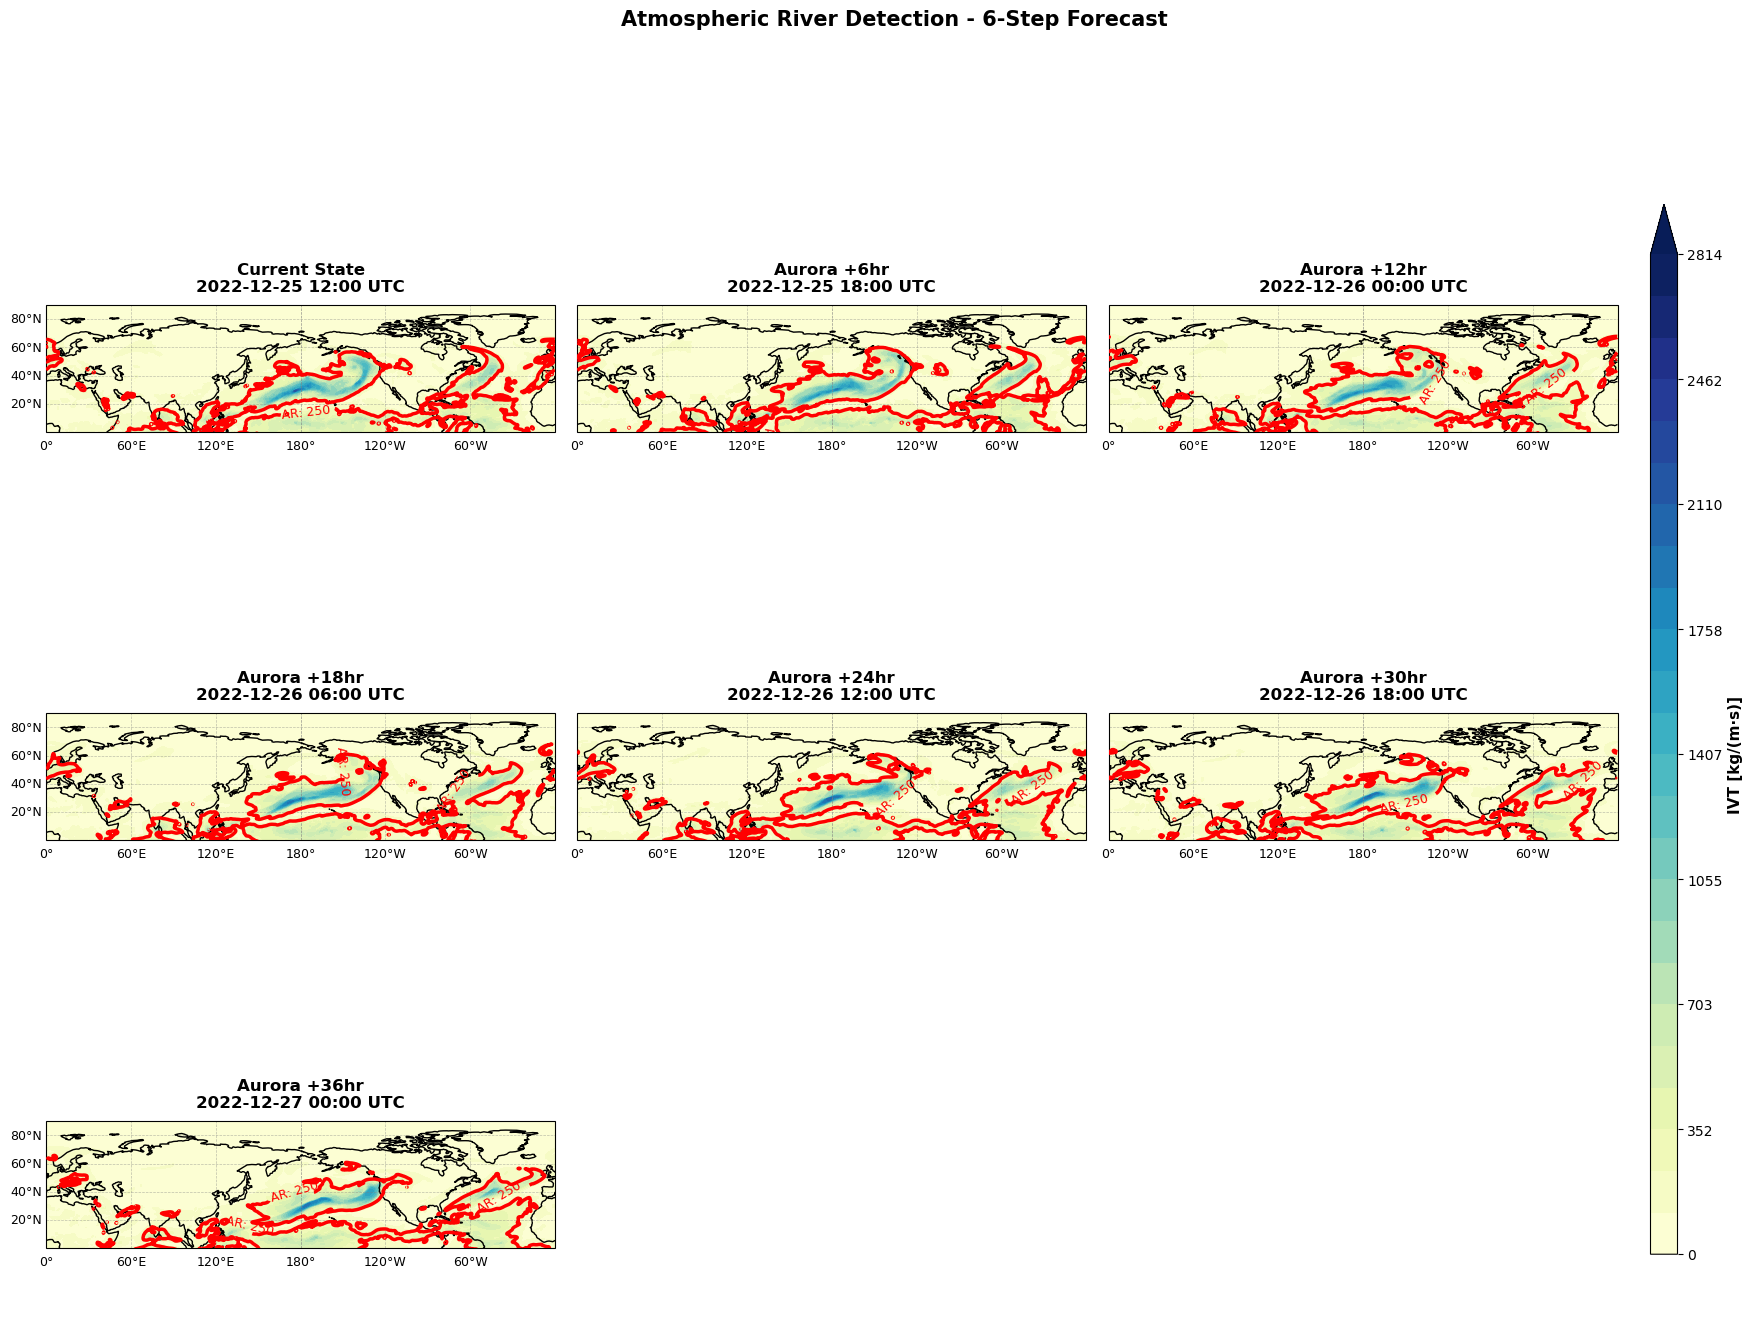

✅ Dynamic IVT comparison plot created!


In [91]:
# Dynamic plot that adjusts to number of prediction steps
if preds_custom is not None and 'ivt_mag_curr_custom' in locals():
    print(f"📊 Creating IVT comparison plots with {num_steps} predictions...")
    
    # Calculate subplot layout
    n_plots = num_steps + 1  # predictions + current state
    n_cols = min(3, n_plots)  # Max 3 columns
    n_rows = (n_plots + n_cols - 1) // n_cols  # Ceiling division
    
    fig_width = 6 * n_cols
    fig_height = 5 * n_rows
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(fig_width, fig_height),
                             subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
    
    # Flatten axes array for easier indexing
    if n_plots == 1:
        axes = np.array([axes])
    else:
        axes = axes.flatten() if n_plots > 1 else [axes]
    
    # Coordinates
    lats = batch_custom.metadata.lat.cpu().numpy()
    lons = batch_custom.metadata.lon.cpu().numpy()
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    extent = [-180, 180, 0, 90]
    
    # Collect all IVT data for consistent color scale
    all_ivt_data = [ivt_mag_curr_custom[0].cpu().numpy()]
    all_ivt_data.extend([ivt_preds_custom[i][2][0].numpy() for i in range(num_steps)])
    
    vmax = max([data.max() for data in all_ivt_data])
    levels = np.linspace(0, vmax, 25)
    ar_threshold = 250
    
    # Plot current state
    ref_time_str = batch_custom.metadata.time[0].strftime('%Y-%m-%d %H:%M UTC')
    titles = [f'Current State\n{ref_time_str}']
    
    # Add prediction titles
    for i in range(num_steps):
        hours_ahead = (i + 1) * 6
        pred_time_str = preds_custom[i].metadata.time[0].strftime('%Y-%m-%d %H:%M UTC')
        titles.append(f'Aurora +{hours_ahead}hr\n{pred_time_str}')
    
    # Plot each panel
    for idx, (ax, title, ivt) in enumerate(zip(axes[:n_plots], titles, all_ivt_data)):
        ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor='black', zorder=3)
        ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray', alpha=0.5)
        ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2, zorder=0)
        
        im = ax.contourf(lon_grid, lat_grid, ivt, levels=levels,
                        cmap='YlGnBu', extend='max', transform=ccrs.PlateCarree(), zorder=2)
        
        if ivt.max() > ar_threshold:
            cs = ax.contour(lon_grid, lat_grid, ivt, levels=[ar_threshold],
                          colors='red', linewidths=2.5, transform=ccrs.PlateCarree(), zorder=4)
            ax.clabel(cs, inline=True, fontsize=9, fmt='AR: 250')
        
        ax.set_title(title, fontsize=12, fontweight='bold', pad=10)
        ax.set_extent(extent, crs=ccrs.PlateCarree(central_longitude=180))
        
        gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
        gl.top_labels = False
        gl.right_labels = False
        if idx % n_cols != 0:
            gl.left_labels = False
        gl.xlabel_style = {'size': 9}
        gl.ylabel_style = {'size': 9}
    
    # Hide unused subplots
    for idx in range(n_plots, len(axes)):
        axes[idx].axis('off')
    
    # Add colorbar
    cbar_ax = fig.add_axes([0.92, 0.15, 0.015, 0.7])
    cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical', extend='max')
    cbar.set_label('IVT [kg/(m·s)]', fontsize=11, fontweight='bold')
    cbar.ax.tick_params(labelsize=10)
    
    plt.suptitle(f'Atmospheric River Detection - {num_steps}-Step Forecast', 
                 fontsize=15, fontweight='bold', y=0.98)
    plt.tight_layout(rect=[0, 0, 0.91, 0.96])
    plt.show()
    
    print("✅ Dynamic IVT comparison plot created!")
else:
    print("⚠️ IVT data not available for plotting")

🔍 Forecast Validation: Aurora vs Real ERA5...

📉 Found 6 forecasts with validation data:

  + 6hr (2022-12-25 18:00:00):
    MAE:      5.3 kg/(m·s)
    RMSE:    10.2 kg/(m·s)
    Bias:    -1.4 kg/(m·s)

  +12hr (2022-12-26 00:00:00):
    MAE:     10.6 kg/(m·s)
    RMSE:    19.9 kg/(m·s)
    Bias:    -2.8 kg/(m·s)

  +18hr (2022-12-26 06:00:00):
    MAE:     12.3 kg/(m·s)
    RMSE:    23.5 kg/(m·s)
    Bias:    -3.3 kg/(m·s)

  +24hr (2022-12-26 12:00:00):
    MAE:     15.9 kg/(m·s)
    RMSE:    30.0 kg/(m·s)
    Bias:    -4.0 kg/(m·s)

  +30hr (2022-12-26 18:00:00):
    MAE:     17.4 kg/(m·s)
    RMSE:    33.0 kg/(m·s)
    Bias:    -4.4 kg/(m·s)

  +36hr (2022-12-27 00:00:00):
    MAE:     20.0 kg/(m·s)
    RMSE:    38.0 kg/(m·s)
    Bias:    -4.6 kg/(m·s)


/tmp/ipykernel_1808912/3360644988.py:101: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.91, 0.96])


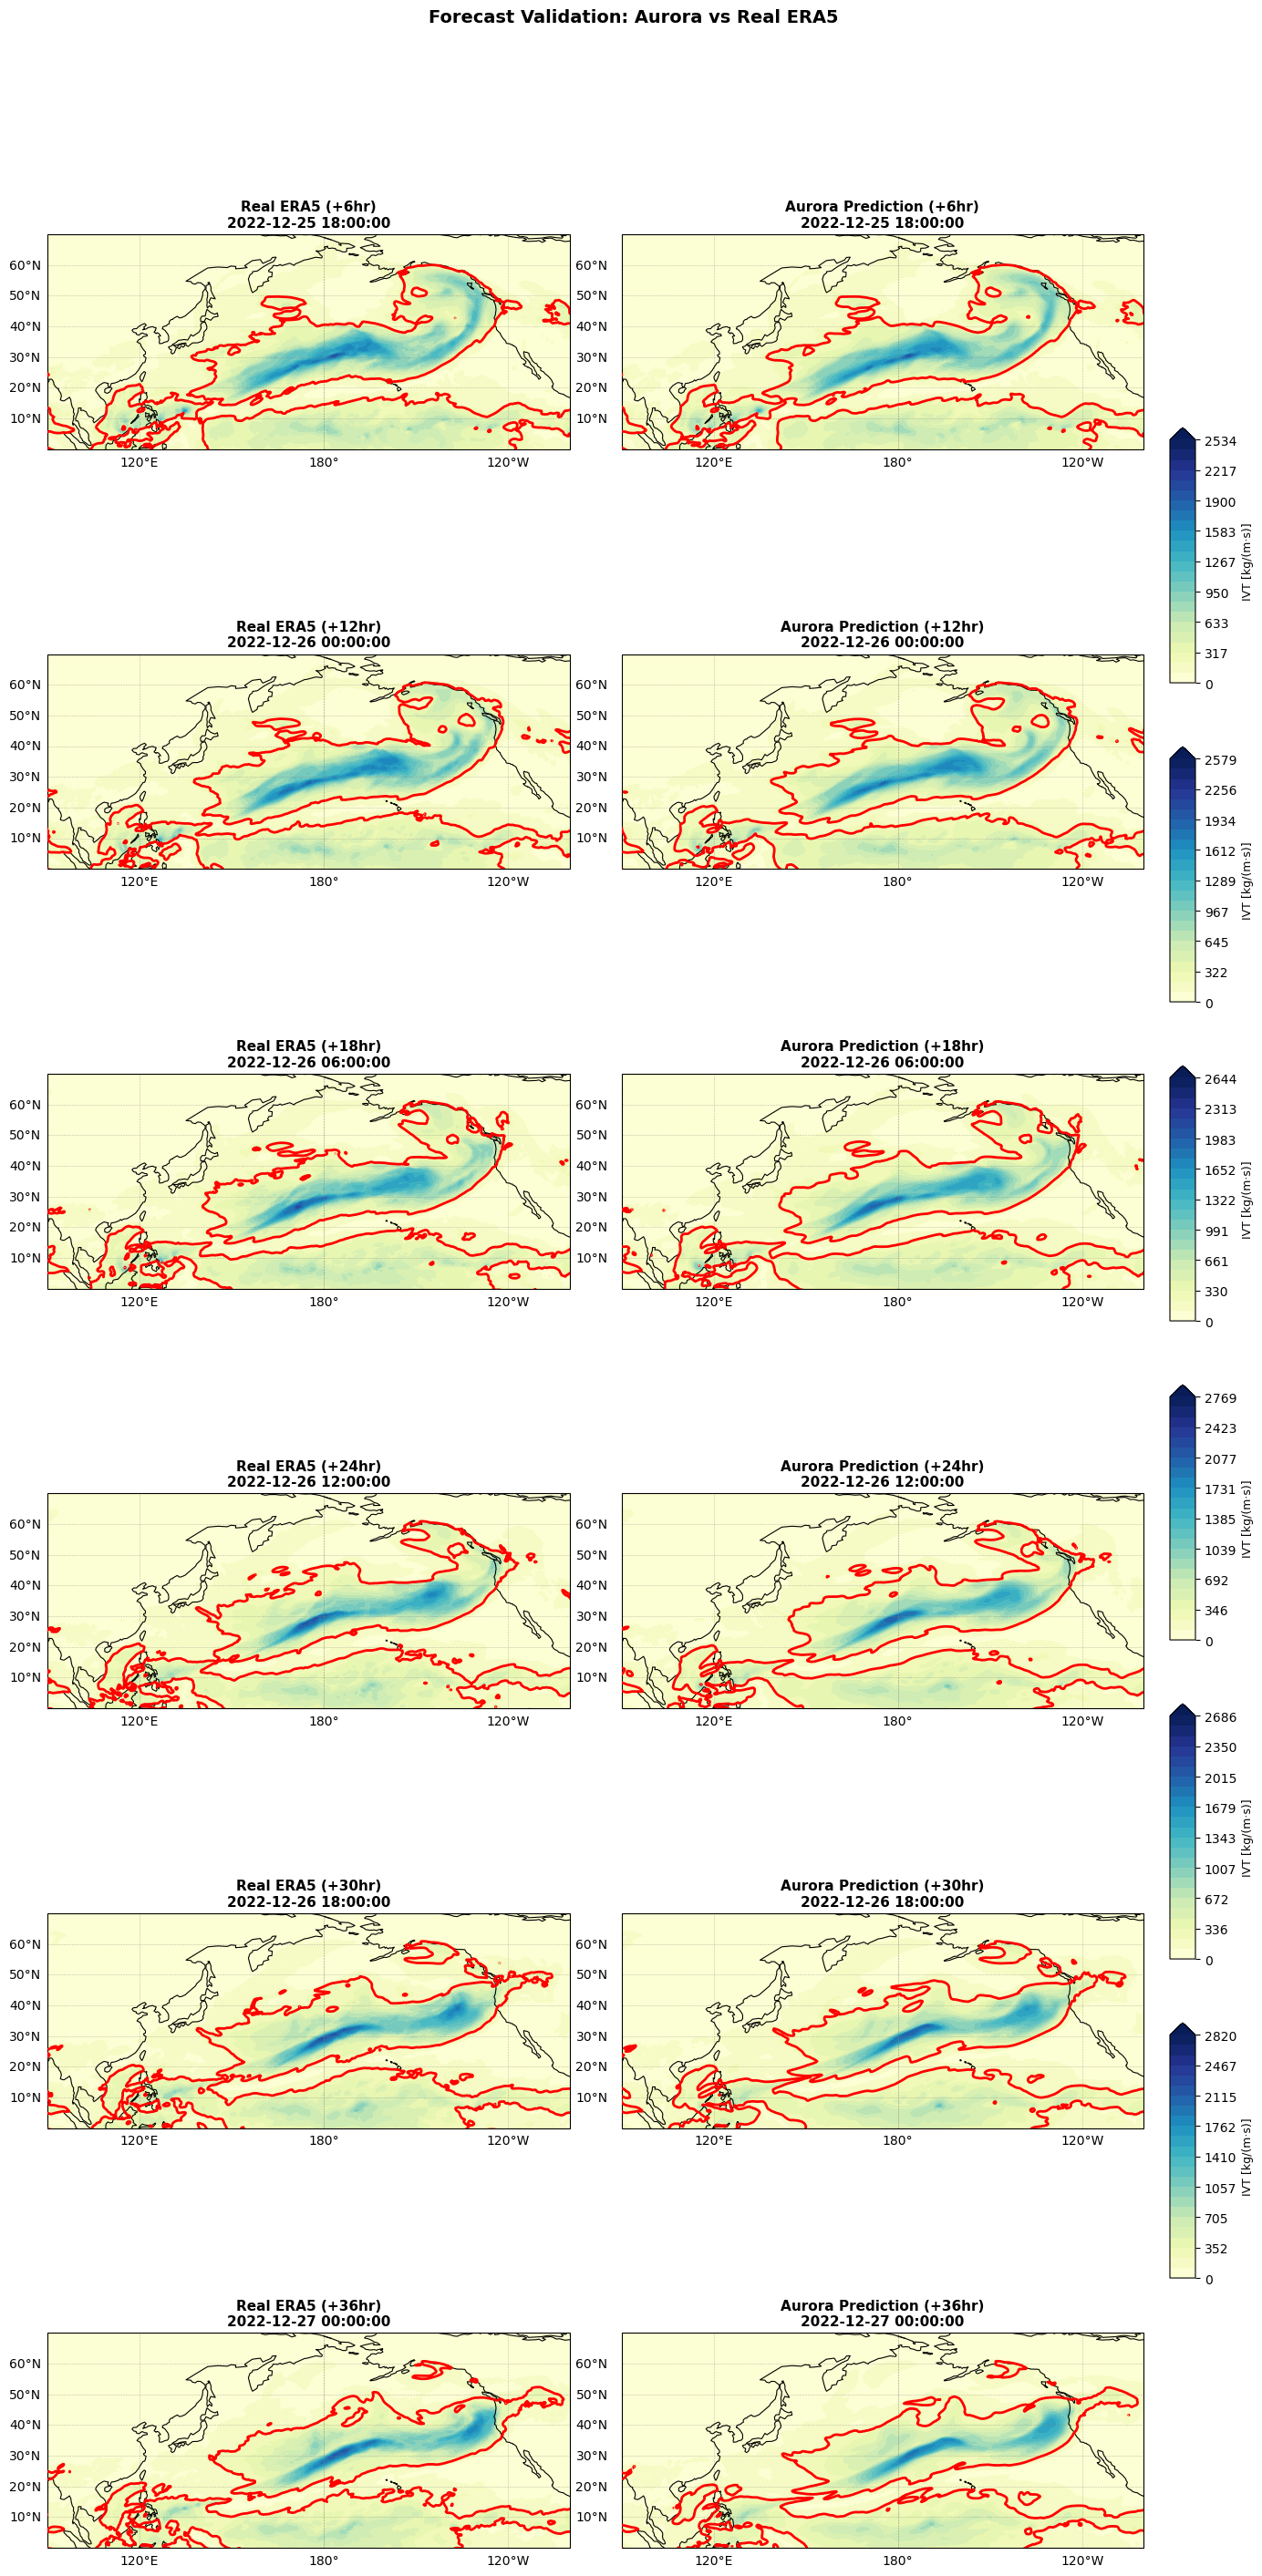


✅ Validation plots created!


In [92]:
# Optional: Validation against real ERA5 (if available in dataset)
if preds_custom is not None and 'ivt_preds_custom' in locals():
    print("🔍 Forecast Validation: Aurora vs Real ERA5...")
    
    # Check which predictions have corresponding real data
    available_times = pd.DatetimeIndex(atmos_vars_ds_full.valid_time.values)
    lat_crop = 720
    lon_crop = 1440
    pressure_levels = batch_custom.metadata.atmos_levels
    
    validations = []
    
    for i, pred in enumerate(preds_custom):
        pred_time = pd.Timestamp(pred.metadata.time[0])
        
        # Check if this prediction time exists in our dataset
        if pred_time in available_times:
            time_idx = available_times.get_loc(pred_time)
            
            # Calculate IVT from real ERA5
            u_real = torch.from_numpy(atmos_vars_ds_full["u"].values[time_idx, :, :lat_crop, :lon_crop])
            v_real = torch.from_numpy(atmos_vars_ds_full["v"].values[time_idx, :, :lat_crop, :lon_crop])
            q_real = torch.from_numpy(atmos_vars_ds_full["q"].values[time_idx, :, :lat_crop, :lon_crop])
            
            _, _, ivt_mag_real = calculate_ivt_integrated(u_real, v_real, q_real, pressure_levels)
            
            # Compare with prediction
            ivt_pred = ivt_preds_custom[i][2][0]
            error = ivt_pred.numpy() - ivt_mag_real.numpy()
            
            mae = np.abs(error).mean()
            rmse = np.sqrt((error**2).mean())
            bias = error.mean()
            
            hours_ahead = (i + 1) * 6
            validations.append({
                'hours': hours_ahead,
                'time': pred_time,
                'mae': mae,
                'rmse': rmse,
                'bias': bias,
                'ivt_real': ivt_mag_real,
                'ivt_pred': ivt_pred
            })
    
    if validations:
        print(f"\n📉 Found {len(validations)} forecasts with validation data:")
        for val in validations:
            print(f"\n  +{val['hours']:2d}hr ({val['time']}):")
            print(f"    MAE:  {val['mae']:7.1f} kg/(m·s)")
            print(f"    RMSE: {val['rmse']:7.1f} kg/(m·s)")
            print(f"    Bias: {val['bias']:+7.1f} kg/(m·s)")
        
        # Create validation plot if we have data
        if len(validations) > 0:
            n_val = len(validations)
            fig, axes = plt.subplots(n_val, 2, figsize=(14, 5*n_val),
                                     subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})
            
            if n_val == 1:
                axes = axes.reshape(1, -1)
            
            lats = batch_custom.metadata.lat.cpu().numpy()
            lons = batch_custom.metadata.lon.cpu().numpy()
            lon_grid, lat_grid = np.meshgrid(lons, lats)
            extent = [-90, 80, 0, 70]
            
            for row, val in enumerate(validations):
                vmax = max(val['ivt_real'].max().item(), val['ivt_pred'].max().item())
                levels = np.linspace(0, vmax, 25)
                
                for col, (data, label) in enumerate([(val['ivt_real'].numpy(), 'Real ERA5'),
                                                      (val['ivt_pred'].numpy(), 'Aurora Prediction')]):
                    ax = axes[row, col]
                    ax.add_feature(cfeature.COASTLINE, linewidth=0.8, edgecolor='black', zorder=3)
                    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3, zorder=1)
                    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.2, zorder=0)
                    
                    im = ax.contourf(lon_grid, lat_grid, data, levels=levels,
                                    cmap='YlGnBu', extend='max', transform=ccrs.PlateCarree(), zorder=2)
                    
                    if data.max() > 250:
                        cs = ax.contour(lon_grid, lat_grid, data, levels=[250],
                                      colors='red', linewidths=2, transform=ccrs.PlateCarree(), zorder=4)
                    
                    ax.set_title(f"{label} (+{val['hours']}hr)\n{val['time']}", 
                               fontsize=11, fontweight='bold')
                    ax.set_extent(extent, crs=ccrs.PlateCarree(central_longitude=180))
                    
                    gl = ax.gridlines(draw_labels=True, linewidth=0.4, color='gray', alpha=0.5, linestyle='--')
                    gl.top_labels = False
                    gl.right_labels = False if col == 1 else True
                    gl.left_labels = True if col == 0 else False
                
                # Add colorbar for this row
                cbar_ax = fig.add_axes([0.92, 0.15 + (n_val-1-row)/n_val*0.7, 0.02, 0.7/n_val*0.8])
                cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
                cbar.set_label('IVT [kg/(m·s)]', fontsize=9)
            
            plt.suptitle('Forecast Validation: Aurora vs Real ERA5', fontsize=14, fontweight='bold', y=0.98)
            plt.tight_layout(rect=[0, 0, 0.91, 0.96])
            plt.show()
            
            print("\n✅ Validation plots created!")
    else:
        print("\n⚠️ No validation data available for these forecast times")
        print(f"   Available times: {available_times[0]} to {available_times[-1]}")
        print(f"   Forecast times: {[pd.Timestamp(p.metadata.time[0]) for p in preds_custom]}")
else:
    print("⚠️ No predictions available for validation")

## Cloud Seeding 1 point example

In [22]:
# ============= CLOUD SEEDING CONFIGURATION =============

# Seeding location (Pacific Ocean)
seeding_location = {
    'lat_center': 26,       # °N (Pacific, upstream of AR)
    'lon_center': 188.00,      # °E (= -140°W in 0-360 format)
    'radius_km': 75,       # km (seeding affected region)
}

# Atmospheric parameters
seeding_params = {
    'layers_mb': [700, 600,500],        # Pressure levels (supercooled layer)
    'freeze_efficiency': 0.80,      # 10% of moisture freezes
    'vertical_coupling': True,      # Spread heat to adjacent levels
    'coupling_factor': 0.1          # Fraction of ΔT to adjacent levels
}

# Physical constants
L_f = 334000  # J/kg (latent heat of freezing)
C_p = 1004    # J/(kg·K) (specific heat of air at constant pressure)
R_earth = 6371  # km (Earth radius)

print("☁️ Cloud Seeding Experiment Configuration")
print("=" * 60)
print(f"📍 Seeding Location: {seeding_location['lat_center']}°N, {seeding_location['lon_center']-360}°W")
print(f"📏 Affected Radius: {seeding_location['radius_km']} km")
print(f"🌡️  Target Layers: {seeding_params['layers_mb']} mb")
print(f"💧 Freeze Efficiency: {seeding_params['freeze_efficiency']*100}%")
print(f"🔥 Latent Heat: L_f = {L_f/1000} kJ/kg")
print("=" * 60)

☁️ Cloud Seeding Experiment Configuration
📍 Seeding Location: 26°N, -172.0°W
📏 Affected Radius: 75 km
🌡️  Target Layers: [700, 600, 500] mb
💧 Freeze Efficiency: 80.0%
🔥 Latent Heat: L_f = 334.0 kJ/kg


In [23]:
# Create spatial mask for seeding region
def create_seeding_mask(lats, lons, seeding_location):
    """
    Create circular mask for cloud seeding region
    
    Args:
        lats: latitude array (degrees)
        lons: longitude array (degrees)
        seeding_location: dict with lat_center, lon_center, radius_km
    
    Returns:
        mask: boolean array [lat, lon]
    """
    lat_center = seeding_location['lat_center']
    lon_center = seeding_location['lon_center']
    radius_km = seeding_location['radius_km']
    
    # Create 2D grids
    lon_grid, lat_grid = np.meshgrid(lons, lats)
    
    # Calculate great circle distance (Haversine formula)
    lat1 = np.radians(lat_grid)
    lat2 = np.radians(lat_center)
    lon1 = np.radians(lon_grid)
    lon2 = np.radians(lon_center)
    
    dlat = lat2 - lat1
    dlon = lon2 - lon1
    
    a = np.sin(dlat/2)**2 + np.cos(lat1) * np.cos(lat2) * np.sin(dlon/2)**2
    c = 2 * np.arcsin(np.sqrt(a))
    distance_km = R_earth * c
    
    # Create circular mask
    mask = distance_km <= radius_km
    
    return mask

# Test the mask with current batch
lats_np = batch_custom.metadata.lat.cpu().numpy()
lons_np = batch_custom.metadata.lon.cpu().numpy()

seeding_mask_spatial = create_seeding_mask(lats_np, lons_np, seeding_location)

print(f"✅ Seeding mask created")
print(f"   Grid points affected: {seeding_mask_spatial.sum()} / {seeding_mask_spatial.size}")
print(f"   Coverage: {seeding_mask_spatial.sum() / seeding_mask_spatial.size * 100:.2f}%")

✅ Seeding mask created
   Grid points affected: 27 / 1036800
   Coverage: 0.00%


In [24]:
# REALISTIC Cloud Seeding Perturbation (with energy balance)
def apply_realistic_cloud_seeding(batch, seeding_mask_spatial, seeding_params):
    """
    Apply realistic cloud seeding perturbation with proper energy balance

    Physics:
    1. Freezing releases latent heat: +L_f
    2. Precipitation removes energy: -(L_v + L_f)
    3. Net effect depends on fallout fraction

    Args:
        batch: Aurora Batch object (will be modified in place)
        seeding_mask_spatial: 2D boolean mask [lat, lon]
        seeding_params: dict with seeding parameters

    Returns:
        delta_T_applied: actual temperature change applied [levels, lat, lon]
    """
    import torch

    # Physical constants
    L_f = 334000   # J/kg (latent heat of fusion - freezing)
    L_v = 2500000  # J/kg (latent heat of vaporization)
    C_p = 1004     # J/(kg·K) (specific heat of air)

    # Find layer indices for seeding
    layer_indices = [batch.metadata.atmos_levels.index(lev)
                     for lev in seeding_params['layers_mb']]

    # Convert spatial mask to torch tensor and move to same device as batch
    device = batch.atmos_vars["t"].device
    mask_torch = torch.from_numpy(seeding_mask_spatial).float().to(device)

    delta_T_applied = torch.zeros_like(batch.atmos_vars["t"][0, 1])

    # Get energy balance method
    method = seeding_params.get('energy_method', 'net_realistic')

    for level_idx in layer_indices:
        # Get specific humidity at this level [batch, lat, lon]
        q_layer = batch.atmos_vars["q"][0, 1, level_idx].clone()

        # Calculate frozen moisture amount (only in seeding region)
        freeze_efficiency = seeding_params.get('freeze_efficiency', 0.30)
        q_frozen = q_layer * freeze_efficiency * mask_torch

        # Calculate temperature change based on method
        if method == 'warming_only':
            # OLD METHOD: Only latent heat release (unrealistic)
            delta_T = (L_f * q_frozen) / C_p
            q_removed = q_frozen

        elif method == 'net_realistic':
            # REALISTIC: Account for precipitation fallout
            fallout_fraction = seeding_params.get('fallout_fraction', 0.7)  # 70% falls out
            q_fallout = q_frozen * fallout_fraction

            # Net energy change:
            # +L_f from freezing, -(L_v + L_f) from fallout
            delta_E = L_f * q_frozen - (L_v + L_f) * q_fallout
            delta_T = delta_E / C_p
            # This is typically NEGATIVE (cooling) if fallout_fraction > 0.12

            q_removed = q_fallout  # Only remove what falls out

        elif method == 'cooling_only':
            # EXTREME: Only precipitation removal (no warming)
            fallout_fraction = seeding_params.get('fallout_fraction', 0.7)
            q_fallout = q_frozen * fallout_fraction
            delta_T = -(L_v + L_f) * q_fallout / C_p  # Pure cooling
            q_removed = q_fallout

        elif method == 'direct':
            # SIMPLE: Direct temperature perturbation (bypass physics)
            delta_T_value = seeding_params.get('direct_delta_T', -1.0)
            delta_T = torch.ones_like(q_layer) * delta_T_value * mask_torch
            q_removed = q_frozen * seeding_params.get('fallout_fraction', 0.5)

        else:
            raise ValueError(f"Unknown energy_method: {method}")

        # Apply to temperature field (both timesteps)
        batch.atmos_vars["t"][0, 0, level_idx] += delta_T
        batch.atmos_vars["t"][0, 1, level_idx] += delta_T

        # Remove moisture (precipitated out)
        batch.atmos_vars["q"][0, 0, level_idx] -= q_removed
        batch.atmos_vars["q"][0, 1, level_idx] -= q_removed

        delta_T_applied[level_idx] = delta_T

        # Vertical coupling (spread temperature change to adjacent levels)
        if seeding_params.get('vertical_coupling', True):
            coupling_factor = seeding_params.get('coupling_factor', 0.3)
            for offset in [-1, 1]:
                adj_idx = level_idx + offset
                if 0 <= adj_idx < len(batch.metadata.atmos_levels):
                    delta_T_adj = delta_T * coupling_factor
                    batch.atmos_vars["t"][0, 0, adj_idx] += delta_T_adj
                    batch.atmos_vars["t"][0, 1, adj_idx] += delta_T_adj
                    delta_T_applied[adj_idx] += delta_T_adj

    return delta_T_applied

In [36]:
# ============= UPDATED SEEDING CONFIGURATION =============

# OPTION 1: REALISTIC (Net cooling from precipitation)
seeding_params_realistic = {
    'layers_mb': [700, 600, 500],
    'freeze_efficiency': 0.30,           # 30% of moisture freezes
    'fallout_fraction': 0.70,            # 70% of frozen water precipitates out
    'energy_method': 'net_realistic',    # Proper energy balance
    'vertical_coupling': True,
    'coupling_factor': 0.4
}

# OPTION 2: STRONG PERTURBATION (Direct cooling for visible effects)
seeding_params_strong = {
    'layers_mb': [700, 600, 500],
    'direct_delta_T': -2.0,              # Direct 2K cooling
    'fallout_fraction': 0.5,             # Remove 50% of moisture
    'energy_method': 'direct',
    'vertical_coupling': True,
    'coupling_factor': 0.5
}

# OPTION 3: OLD METHOD (Just warming - for comparison)
seeding_params_old = {
    'layers_mb': [700, 600],
    'freeze_efficiency': 0.50,
    'energy_method': 'warming_only',     # Unrealistic but shows chaos
    'vertical_coupling': True,
    'coupling_factor': 0.3
}

In [37]:
# Create perturbed batch (clone original to preserve control)
batch_control = batch_custom
batch_seeded = Batch(
    surf_vars={k: v.clone() for k, v in batch_custom.surf_vars.items()},
    atmos_vars={k: v.clone() for k, v in batch_custom.atmos_vars.items()},
    static_vars={k: v.clone() for k, v in batch_custom.static_vars.items()},
    metadata=batch_custom.metadata
).to("cuda")

# Apply REALISTIC seeding perturbation
delta_T_field = apply_realistic_cloud_seeding(
    batch_seeded,
    seeding_mask_spatial,
    # seeding_params_realistic  # Use realistic method
    seeding_params_strong
)

# Report perturbation magnitude
layer_idx_600 = batch_custom.metadata.atmos_levels.index(600)
max_delta_T = delta_T_field[layer_idx_600][seeding_mask_spatial].max().item()
mean_delta_T = delta_T_field[layer_idx_600][seeding_mask_spatial].mean().item()
min_delta_T = delta_T_field[layer_idx_600][seeding_mask_spatial].min().item()

print("☁️ REALISTIC Cloud Seeding Perturbation Applied")
print("=" * 60)
print(f"🌡️  Temperature change at 600mb:")
print(f"   Maximum ΔT: {max_delta_T:+.3f} K")
print(f"   Mean ΔT:    {mean_delta_T:+.3f} K")
print(f"   Minimum ΔT: {min_delta_T:+.3f} K")
print(f"💧 Moisture removed (precipitated)")
print(f"⚖️  Energy balance: Realistic (cooling expected)")
print("=" * 60)
print("✅ Perturbed batch ready for prediction")

☁️ REALISTIC Cloud Seeding Perturbation Applied
🌡️  Temperature change at 600mb:
   Maximum ΔT: -3.000 K
   Mean ΔT:    -3.000 K
   Minimum ΔT: -3.000 K
💧 Moisture removed (precipitated)
⚖️  Energy balance: Realistic (cooling expected)
✅ Perturbed batch ready for prediction


In [38]:
num_steps = 6

In [39]:
# Run both control and seeded predictions
print("🚀 Running Control and Seeded Predictions...")
print("=" * 60)

# Move model to CUDA if needed
if next(model.parameters()).device.type == 'cpu':
    model = model.to("cuda")

with torch.inference_mode():
    # Control run (original)
    print("1️⃣ Control run (no seeding)...")
    preds_control = [pred.to("cpu") for pred in rollout(model, batch_control, steps=num_steps)]
    print(f"   ✅ Control predictions: {len(preds_control)} steps")
    
    # Seeded run (with perturbation)
    print("2️⃣ Seeded run (with cloud seeding)...")
    preds_seeded = [pred.to("cpu") for pred in rollout(model, batch_seeded, steps=num_steps)]
    print(f"   ✅ Seeded predictions: {len(preds_seeded)} steps")

# Move model back to CPU
model = model.to("cpu")

print("\n✅ Both predictions completed!")
print(f"   Forecast horizon: +{num_steps*6} hours")
print(f"   Time steps: ", [f"+{(i+1)*6}hr" for i in range(num_steps)])

🚀 Running Control and Seeded Predictions...
1️⃣ Control run (no seeding)...
   ✅ Control predictions: 6 steps
2️⃣ Seeded run (with cloud seeding)...
   ✅ Seeded predictions: 6 steps

✅ Both predictions completed!
   Forecast horizon: +36 hours
   Time steps:  ['+6hr', '+12hr', '+18hr', '+24hr', '+30hr', '+36hr']


In [40]:
# Calculate IVT for both control and seeded predictions
print("🌊 Calculating IVT for trajectory tracking...")

pressure_levels = batch_control.metadata.atmos_levels

# Control IVT
ivt_control = []
for i, pred in enumerate(preds_control):
    u = pred.atmos_vars["u"][:, 0]
    v = pred.atmos_vars["v"][:, 0]
    q = pred.atmos_vars["q"][:, 0]
    _, _, ivt_mag = calculate_ivt_integrated(u, v, q, pressure_levels)
    ivt_control.append(ivt_mag[0].numpy())

# Seeded IVT
ivt_seeded = []
for i, pred in enumerate(preds_seeded):
    u = pred.atmos_vars["u"][:, 0]
    v = pred.atmos_vars["v"][:, 0]
    q = pred.atmos_vars["q"][:, 0]
    _, _, ivt_mag = calculate_ivt_integrated(u, v, q, pressure_levels)
    ivt_seeded.append(ivt_mag[0].numpy())

# Calculate IVT differences
ivt_diff = [seeded - control for seeded, control in zip(ivt_seeded, ivt_control)]

print(f"✅ IVT calculated for {len(ivt_control)} time steps")
print(f"\n📊 IVT Difference Stats (Seeded - Control):")
for i, diff in enumerate(ivt_diff):
    hours = (i+1)*6
    max_diff = np.abs(diff).max()
    mean_diff = diff.mean()
    print(f"   +{hours:2d}hr: Max |Δ|={max_diff:6.1f}, Mean Δ={mean_diff:+6.1f} kg/(m·s)")

🌊 Calculating IVT for trajectory tracking...
✅ IVT calculated for 6 time steps

📊 IVT Difference Stats (Seeded - Control):
   + 6hr: Max |Δ|=   9.4, Mean Δ=  +0.0 kg/(m·s)
   +12hr: Max |Δ|=  14.4, Mean Δ=  -0.0 kg/(m·s)
   +18hr: Max |Δ|=  14.6, Mean Δ=  -0.0 kg/(m·s)
   +24hr: Max |Δ|=  14.5, Mean Δ=  +0.0 kg/(m·s)
   +30hr: Max |Δ|=  14.1, Mean Δ=  -0.0 kg/(m·s)
   +36hr: Max |Δ|=  15.2, Mean Δ=  -0.0 kg/(m·s)


📊 Creating IVT anomaly maps (Seeded − Control)...


/tmp/ipykernel_1240825/2123747350.py:114: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.99])


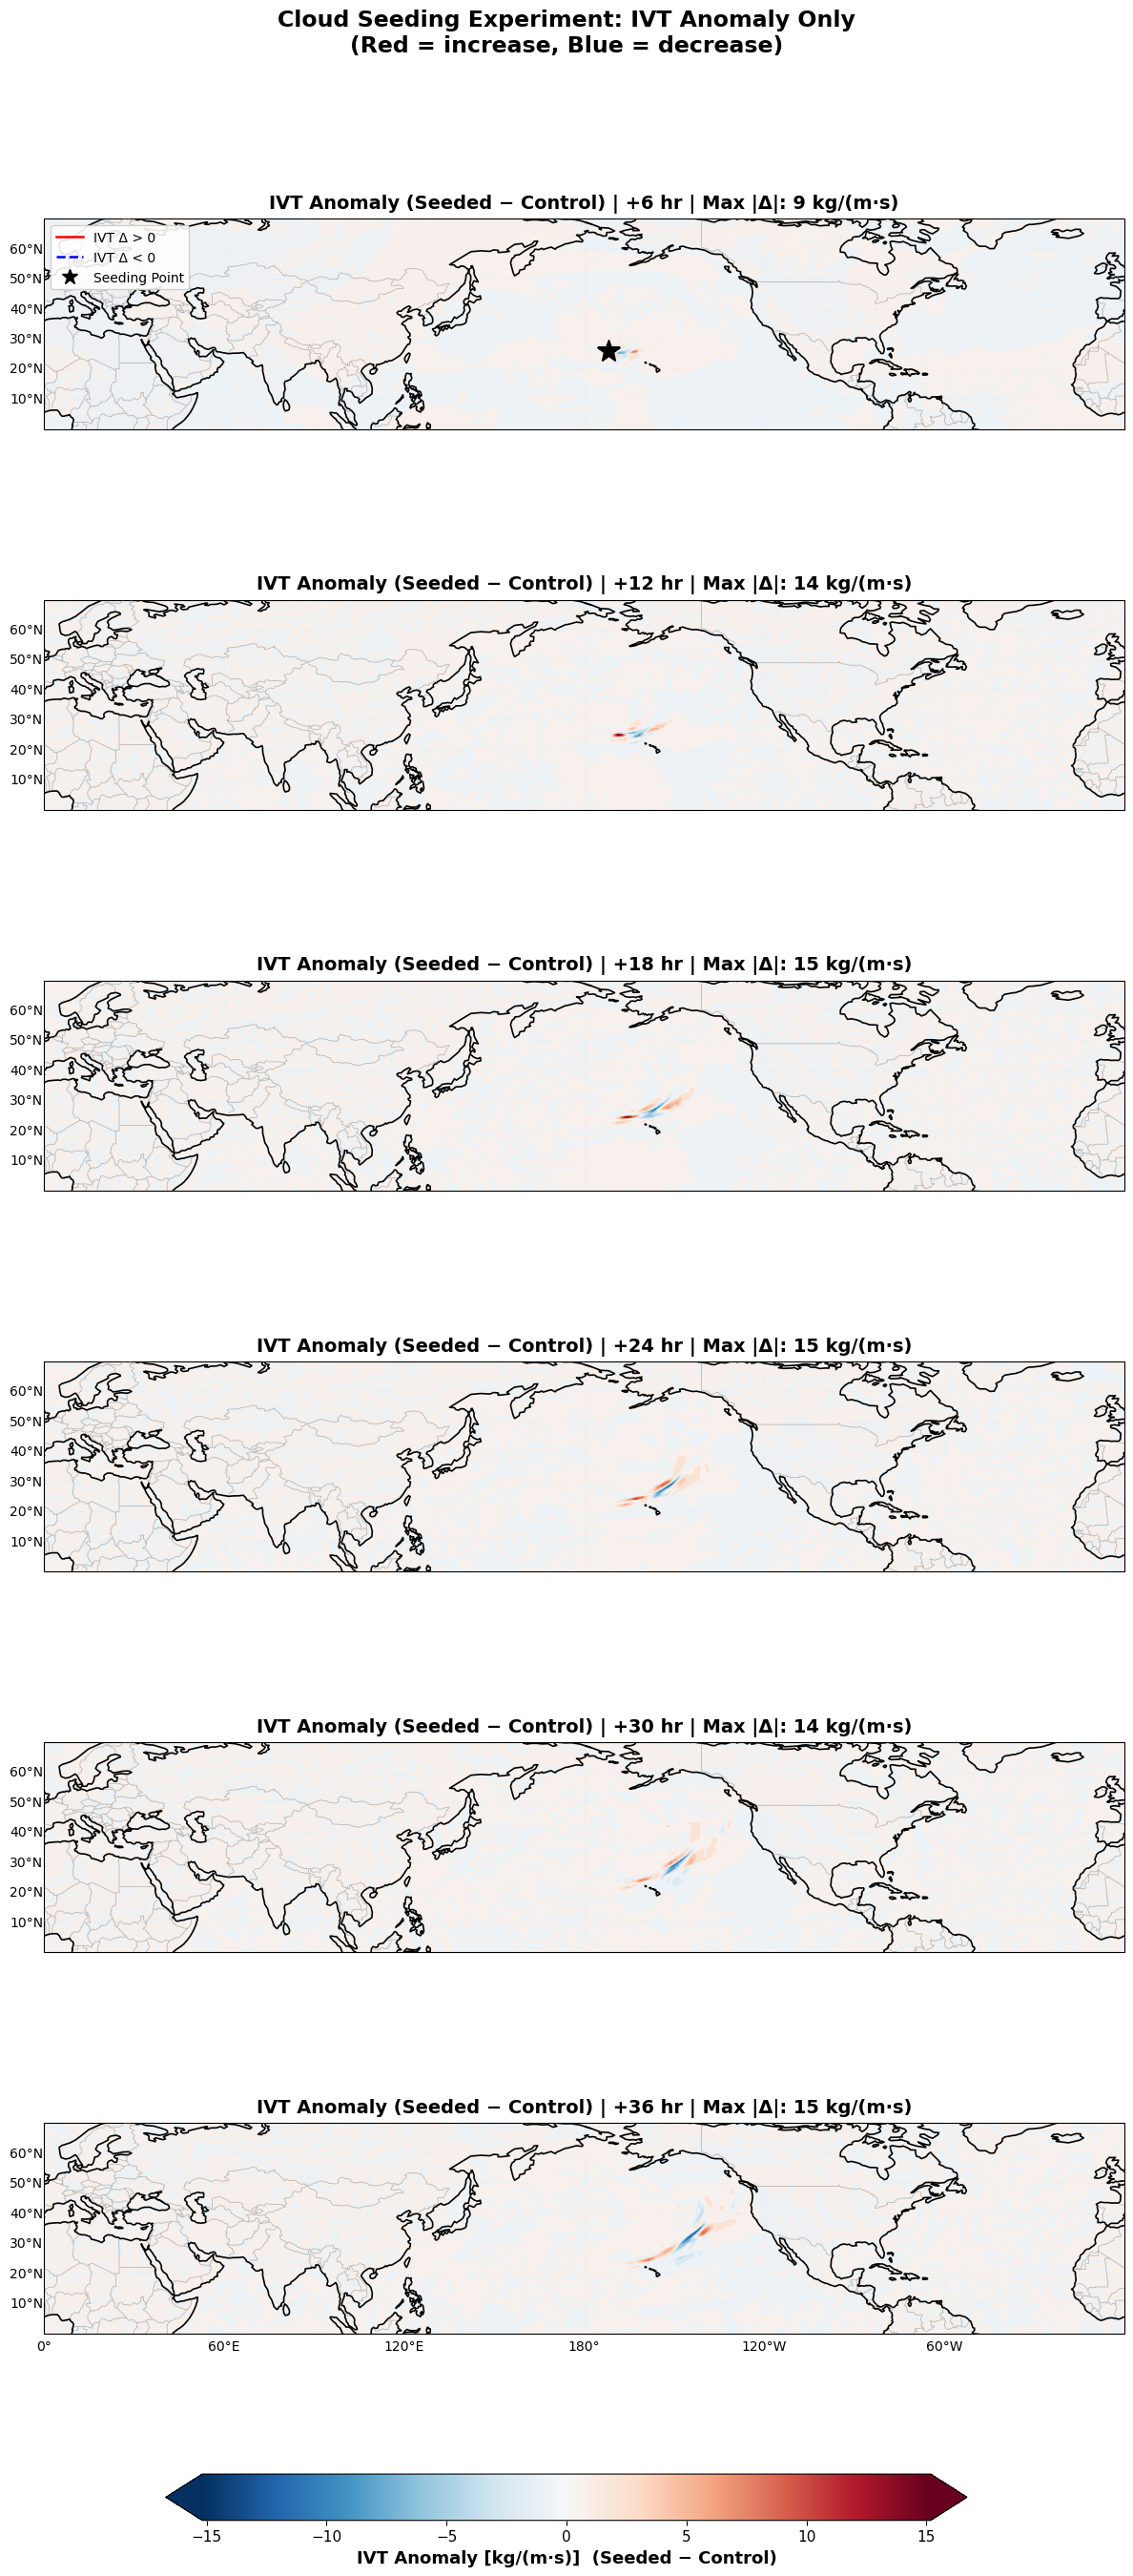

✅ IVT anomaly visualization complete!


In [41]:
print("📊 Creating IVT anomaly maps (Seeded − Control)...")

# ---------- Setup ----------
proj = ccrs.PlateCarree(central_longitude=180)
data_crs = ccrs.PlateCarree()
extent = [-180, 180, 0, 70]  # NH focus

lon_grid, lat_grid = np.meshgrid(lons_np, lats_np)

# NaN-safe copies
ivt_diff = [np.array(a, dtype=float) for a in ivt_diff]
n_steps = len(ivt_diff)

# ---------- Shared symmetric color scale across ALL steps ----------
amax = np.nanmax([np.nanmax(np.abs(x)) for x in ivt_diff])
# avoid degenerate scale
amax = 1.0 if not np.isfinite(amax) or amax == 0 else amax
levels = np.linspace(-amax, amax, 21)

fig, axes = plt.subplots(
    n_steps, 1,
    figsize=(12, max(4.5*n_steps, 5)),
    subplot_kw={'projection': proj}
)

if n_steps == 1:
    axes = np.array([axes])

# Optional labeled contour levels for emphasis
neg_lvls = [-300, -200, -100, -50]
pos_lvls = [50, 100, 200, 300]

# ---------- Helper: geodesic ring ----------
def plot_geodesic_ring(ax, lon, lat, radius_km, n=180, **kwargs):
    from cartopy.geodesic import Geodesic
    g = Geodesic()
    poly = g.circle(lon=lon, lat=lat, radius=radius_km*1000.0, n_samples=n)
    xs, ys = zip(*poly)
    ax.plot(xs, ys, transform=ccrs.Geodetic(), **kwargs)

for idx in range(n_steps):
    hours = (idx+1)*6
    ax = axes[idx]

    # Base map
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.4, zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.25, zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black', zorder=4)
    ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='gray', alpha=0.5, zorder=4)
    ax.set_extent(extent, crs=data_crs)

    gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
    gl.top_labels = False
    gl.right_labels = False
    gl.bottom_labels = (idx == n_steps - 1)
    gl.left_labels = True
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Anomaly fill (Seeded − Control)
    diff = ivt_diff[idx]
    im = ax.contourf(
        lon_grid, lat_grid, diff,
        levels=levels, cmap='RdBu_r', extend='both',
        transform=data_crs, alpha=0.9, zorder=2
    )

    # Optional labeled anomaly contours for emphasis
    if np.nanmin(diff) < min(neg_lvls):
        cs_neg = ax.contour(lon_grid, lat_grid, diff, levels=neg_lvls,
                            colors='blue', linewidths=1.8, linestyles='--',
                            transform=data_crs, zorder=5)
        ax.clabel(cs_neg, inline=True, fontsize=9, fmt='%d')
    if np.nanmax(diff) > max(pos_lvls):
        cs_pos = ax.contour(lon_grid, lat_grid, diff, levels=pos_lvls,
                            colors='red', linewidths=1.8, linestyles='-',
                            transform=data_crs, zorder=5)
        ax.clabel(cs_pos, inline=True, fontsize=9, fmt='+%d')

    # Seeding context (only first row to reduce clutter)
    if idx == 0:
        ax.plot(seeding_location['lon_center'], seeding_location['lat_center'],
                marker='*', markersize=18, color='k', transform=data_crs, zorder=10)
        plot_geodesic_ring(ax,
                           seeding_location['lon_center'],
                           seeding_location['lat_center'],
                           seeding_location['radius_km'],
                           n=180, linewidth=2.0, linestyle=':', color='k')
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='red', linewidth=1.8, linestyle='-', label='IVT Δ > 0'),
            Line2D([0], [0], color='blue', linewidth=1.8, linestyle='--', label='IVT Δ < 0'),
            Line2D([0], [0], marker='*', color='k', linewidth=0, markersize=12, label='Seeding Point')
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.9)

    max_abs = np.nanmax(np.abs(diff))
    ax.set_title(f'IVT Anomaly (Seeded − Control) | +{hours} hr | Max |Δ|: {max_abs:.0f} kg/(m·s)',
                 fontsize=14, fontweight='bold', pad=8)

# Shared colorbar (symmetric)
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize
sm = ScalarMappable(norm=Normalize(vmin=-amax, vmax=amax), cmap='RdBu_r')
sm.set_array([])

cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.018])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label('IVT Anomaly [kg/(m·s)]  (Seeded − Control)', fontsize=13, fontweight='bold')
cbar.ax.tick_params(labelsize=11)

plt.suptitle('Cloud Seeding Experiment: IVT Anomaly Only\n(Red = increase, Blue = decrease)',
             fontsize=17, fontweight='bold', y=0.995)
plt.tight_layout(rect=[0, 0.04, 1, 0.99])
plt.show()

print("✅ IVT anomaly visualization complete!")


In [23]:
# # Visualize IVT maps - TWO COLUMNS: Control vs Seeded
# print("📊 Creating IVT comparison: Control vs Seeded...")

# n_steps = len(ivt_control)
# n_cols = 2  # TWO COLUMNS: Control | Seeded
# n_rows = n_steps  # ONE ROW PER TIME STEP

# fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5*n_rows),
#                          subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)})

# # Handle single vs multiple rows
# if n_steps == 1:
#     axes = axes.reshape(1, -1)

# # Coordinates
# lon_grid, lat_grid = np.meshgrid(lons_np, lats_np)
# extent = [-180, 180, 0, 70]  # Pacific to West Coast

# # Seeding location marker
# seed_lon = seeding_location['lon_center']
# seed_lat = seeding_location['lat_center']

# for idx in range(n_steps):
#     hours = (idx+1)*6

#     # Column 0: CONTROL (no seeding)
#     ax_control = axes[idx, 0]

#     # Column 1: SEEDED (with perturbation)
#     ax_seeded = axes[idx, 1]

#     # Common max for consistent color scale
#     vmax = max(ivt_control[idx].max(), ivt_seeded[idx].max())
#     levels_ivt = np.linspace(0, vmax, 20)

#     # ========== LEFT PANEL: CONTROL ==========
#     ax_control.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black', zorder=4)
#     ax_control.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='gray', alpha=0.5)
#     ax_control.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.4, zorder=1)
#     ax_control.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3, zorder=0)

#     im_control = ax_control.contourf(lon_grid, lat_grid, ivt_control[idx], levels=levels_ivt,
#                     cmap='YlGnBu', extend='max', transform=ccrs.PlateCarree(),
#                     alpha=0.7, zorder=2)

#     ax_control.set_title(f'Control (No Seeding) | +{hours}hr',
#                 fontsize=14, fontweight='bold', pad=10)
#     ax_control.set_extent(extent, crs=ccrs.PlateCarree(central_longitude=180))

#     gl_c = ax_control.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
#     gl_c.top_labels = False
#     gl_c.right_labels = False
#     gl_c.bottom_labels = True if idx == n_steps - 1 else False
#     gl_c.xlabel_style = {'size': 10}
#     gl_c.ylabel_style = {'size': 10}


#     # ========== RIGHT PANEL: SEEDED with ANOMALY CONTOURS ==========
#     ax_seeded.add_feature(cfeature.COASTLINE, linewidth=1.5, edgecolor='black', zorder=4)
#     ax_seeded.add_feature(cfeature.BORDERS, linewidth=0.8, edgecolor='gray', alpha=0.5)
#     ax_seeded.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.4, zorder=1)
#     ax_seeded.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.3, zorder=0)

#     im_seeded = ax_seeded.contourf(lon_grid, lat_grid, ivt_seeded[idx], levels=levels_ivt,
#                     cmap='YlGnBu', extend='max', transform=ccrs.PlateCarree(),
#                     alpha=0.7, zorder=2)

#     # Overlay IVT ANOMALY (seeded - control) as contours
#     diff = ivt_diff[idx]

#     # Negative anomalies (weakening) - dashed blue
#     if diff.min() < -40:
#         cs_neg = ax_seeded.contour(lon_grid, lat_grid, diff, levels=[-300, -200, -100, -50],
#                            colors='blue', linewidths=2.5, linestyles='--',
#                            transform=ccrs.PlateCarree(), zorder=5)
#         ax_seeded.clabel(cs_neg, inline=True, fontsize=9, fmt='%d')

#     # Positive anomalies (strengthening) - solid red
#     if diff.max() > 40:
#         cs_pos = ax_seeded.contour(lon_grid, lat_grid, diff, levels=[50, 100, 200, 300],
#                            colors='red', linewidths=2.5, linestyles='-',
#                            transform=ccrs.PlateCarree(), zorder=5)
#         ax_seeded.clabel(cs_pos, inline=True, fontsize=9, fmt='+%d')

#     # Plot seeding location
#     if idx == 0:
#         ax_seeded.plot(seed_lon, seed_lat, 'k*', markersize=25,
#                transform=ccrs.PlateCarree(), zorder=10,
#                label='Seeding Location')
#         circle = plt.Circle((seed_lon, seed_lat), seeding_location['radius_km']/111,
#                            color='black', fill=False, linewidth=2.5, linestyle=':',
#                            transform=ccrs.PlateCarree(), zorder=10)
#         ax_seeded.add_patch(circle)

#     # Title with max anomaly
#     max_anom = np.abs(diff).max()
#     ax_seeded.set_title(f'Seeded | +{hours}hr | Max Δ: {max_anom:.0f} kg/(m·s)',
#                 fontsize=14, fontweight='bold', pad=10)
#     ax_seeded.set_extent(extent, crs=ccrs.PlateCarree(central_longitude=180))

#     gl_s = ax_seeded.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
#     gl_s.top_labels = False
#     gl_s.right_labels = False
#     gl_s.left_labels = False
#     gl_s.bottom_labels = True if idx == n_steps - 1 else False
#     gl_s.xlabel_style = {'size': 10}
#     gl_s.ylabel_style = {'size': 10}

#     # Legend (only first row, right panel)
#     if idx == 0:
#         from matplotlib.lines import Line2D
#         legend_elements = [
#             Line2D([0], [0], color='red', linewidth=2.5, linestyle='-', label='IVT Increase'),
#             Line2D([0], [0], color='blue', linewidth=2.5, linestyle='--', label='IVT Decrease'),
#             Line2D([0], [0], marker='*', color='k', linewidth=0, markersize=15, label='Seeding Point')
#         ]
#         ax_seeded.legend(handles=legend_elements, loc='upper left', fontsize=10, framealpha=0.9)

# # Shared colorbar at bottom
# cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.015])
# cbar = fig.colorbar(im_seeded, cax=cbar_ax, orientation='horizontal', extend='max')
# cbar.set_label('IVT [kg/(m·s)]', fontsize=13, fontweight='bold')
# cbar.ax.tick_params(labelsize=11)

# plt.suptitle('Cloud Seeding Experiment: Control vs Seeded Comparison\n(Red contours = IVT increase, Blue contours = IVT decrease)',
#              fontsize=17, fontweight='bold', y=0.995)
# plt.tight_layout(rect=[0, 0.04, 1, 0.99])
# plt.show()

# print("✅ IVT comparison visualization complete!")


# # Print anomaly statistics
# print("\n📊 IVT Anomaly Statistics (Seeded - Control):")
# print("=" * 60)
# for i, diff in enumerate(ivt_diff):
#     hours = (i+1)*6
#     max_increase = diff.max()
#     max_decrease = diff.min()
#     mean_change = diff.mean()
#     rms_change = np.sqrt((diff**2).mean())

#     print(f"+{hours:2d}hr:")
#     print(f"  Max Increase:  {max_increase:+7.1f} kg/(m·s)")
#     print(f"  Max Decrease:  {max_decrease:+7.1f} kg/(m·s)")
#     print(f"  Mean Change:   {mean_change:+7.1f} kg/(m·s)")
#     print(f"  RMS Change:    {rms_change:7.1f} kg/(m·s)")
# print("=" * 60)

## Continuous Perturbation at Every Time Step

Instead of perturbing only the initial condition, we now apply the seeding perturbation **at every time step** during the forecast. This simulates continuous cloud seeding throughout the entire forecast period.

In [14]:
from matplotlib.patches import Circle
from copy import deepcopy
from tqdm import tqdm

In [42]:
def apply_realistic_cloud_seeding_single_timestep(batch, seeding_mask_spatial, seeding_params, timestep_idx=1):
  """
  Apply realistic cloud seeding to ONE timestep in the batch.
  
  For continuous perturbation experiments where you want to apply seeding
  at each forecast step without double-counting.
  
  Args:
      batch: Aurora Batch object with 2 timesteps [t-1, t]
      seeding_mask_spatial: 2D boolean/float array [lat, lon] for seeding region
      seeding_params: Dict with keys:
          - 'layers_mb': list of pressure levels (e.g., [500, 600, 700])
          - 'freeze_efficiency': fraction of moisture that freezes (0.0-1.0)
          - 'fallout_fraction': fraction of frozen moisture that precipitates (0.0-1.0)
          - 'energy_method': 'net_realistic', 'warming_only', 'cooling_only', or 'direct'
          - 'vertical_coupling': bool, whether to spread heat to adjacent levels
          - 'coupling_factor': float, fraction of ΔT to spread (e.g., 0.4)
      timestep_idx: Which timestep to perturb (0 or 1)
          - 0: perturb t-1 (previous time)
          - 1: perturb t (current time) [DEFAULT]
  
  Returns:
      delta_T_applied: Temperature change applied at each level [levels, lat, lon]
  """
  import torch

  # Physical constants
  L_f = 334000   # J/kg (latent heat of fusion - freezing)
  L_v = 2500000  # J/kg (latent heat of vaporization)
  C_p = 1004     # J/(kg·K) (specific heat of air)

  # Find layer indices for seeding
  layer_indices = [batch.metadata.atmos_levels.index(lev)
                   for lev in seeding_params['layers_mb']]

  # Convert spatial mask to torch tensor
  device = batch.atmos_vars["t"].device
  mask_torch = torch.from_numpy(seeding_mask_spatial).float().to(device)

  delta_T_applied = torch.zeros_like(batch.atmos_vars["t"][0, timestep_idx])

  # Get energy balance method
  method = seeding_params.get('energy_method', 'net_realistic')

  for level_idx in layer_indices:
      # Get specific humidity at this level for the specified timestep ONLY
      q_layer = batch.atmos_vars["q"][0, timestep_idx, level_idx].clone()

      # Calculate frozen moisture amount (only in seeding region)
      freeze_efficiency = seeding_params.get('freeze_efficiency', 0.30)
      q_frozen = q_layer * freeze_efficiency * mask_torch

      # Calculate temperature change based on method
      if method == 'warming_only':
          # OLD METHOD: Only latent heat release (unrealistic)
          delta_T = (L_f * q_frozen) / C_p
          q_removed = q_frozen

      elif method == 'net_realistic':
          # REALISTIC: Account for precipitation fallout
          fallout_fraction = seeding_params.get('fallout_fraction', 0.7)  # 70% falls out
          q_fallout = q_frozen * fallout_fraction

          # Net energy change:
          # +L_f from freezing, -(L_v + L_f) from fallout
          delta_E = L_f * q_frozen - (L_v + L_f) * q_fallout
          delta_T = delta_E / C_p
          # This is typically NEGATIVE (cooling) if fallout_fraction > 0.12

          q_removed = q_fallout  # Only remove what falls out

      elif method == 'cooling_only':
          # EXTREME: Only precipitation removal (no warming)
          fallout_fraction = seeding_params.get('fallout_fraction', 0.7)
          q_fallout = q_frozen * fallout_fraction
          delta_T = -(L_v + L_f) * q_fallout / C_p  # Pure cooling
          q_removed = q_fallout

      elif method == 'direct':
          # SIMPLE: Direct temperature perturbation (bypass physics)
          delta_T_value = seeding_params.get('direct_delta_T', -1.0)
          delta_T = torch.ones_like(q_layer) * delta_T_value * mask_torch
          q_removed = q_frozen * seeding_params.get('fallout_fraction', 0.5)

      else:
          raise ValueError(f"Unknown energy_method: {method}")

      # Apply to temperature field (ONLY the specified timestep)
      batch.atmos_vars["t"][0, timestep_idx, level_idx] += delta_T

      # Remove moisture (ONLY the specified timestep)
      batch.atmos_vars["q"][0, timestep_idx, level_idx] -= q_removed

      # Track applied change
      delta_T_applied[level_idx] = delta_T

      # Optional: vertical coupling to adjacent levels
      if seeding_params.get('vertical_coupling', False):
          coupling_factor = seeding_params.get('coupling_factor', 0.4)

          # Spread to level above (lower pressure)
          if level_idx > 0:
              batch.atmos_vars["t"][0, timestep_idx, level_idx-1] += delta_T * coupling_factor

          # Spread to level below (higher pressure)
          if level_idx < len(batch.metadata.atmos_levels) - 1:
              batch.atmos_vars["t"][0, timestep_idx, level_idx+1] += delta_T * coupling_factor

  return delta_T_applied

In [ ]:
# CONTINUOUS PERTURBATION: Perturb only current timestep at each step

print("="*80)
print("Running forecast with CONTINUOUS PERTURBATION (single timestep)")
print("="*80)

# Use the same seeding location and parameters
lats = batch_custom.metadata.lat.cpu().numpy()
lons = batch_custom.metadata.lon.cpu().numpy()
seeding_mask_spatial = create_seeding_mask(lats, lons, seeding_location)

print(f"Seeding location: {seeding_location['lat_center']:.1f}°N, {seeding_location['lon_center']:.1f}°E")
print(f"Running {num_steps} sequential 1-step forecasts with perturbation at EACH step...")
print("Perturbing only the CURRENT timestep (t=1) at each iteration")

# Store predictions
preds_continuous = []

# Start with original batch data
prev_surf = {k: v.cpu().numpy().copy() for k, v in batch_custom.surf_vars.items()}
prev_atmos = {k: v.cpu().numpy().copy() for k, v in batch_custom.atmos_vars.items()}

for step in range(num_steps):
  print(f"  Step {step+1}/{num_steps}: Perturb current time → Forecast...")

  # Create FRESH batch from saved numpy data
  batch_fresh = Batch(
      surf_vars={k: torch.from_numpy(v.copy()) for k, v in prev_surf.items()},
      atmos_vars={k: torch.from_numpy(v.copy()) for k, v in prev_atmos.items()},
      static_vars={k: v.clone() for k, v in batch_custom.static_vars.items()},
      metadata=batch_custom.metadata
  ).to("cuda")

  # ========== KEY FIX: Only perturb timestep 1 (current time) ==========
  delta_T = apply_realistic_cloud_seeding_single_timestep(
      batch_fresh,
      seeding_mask_spatial,
      #seeding_params_realistic,
      seeding_params_strong,
      timestep_idx=1  # Only perturb the second/current timestep
  )

  # Run 1 step forecast
  with torch.inference_mode():
      pred_list = [pred for pred in rollout(model, batch_fresh, steps=1)]

  pred = pred_list[0]
  preds_continuous.append(pred)

  # Prepare next iteration: [t_current_perturbed, t_next_predicted]
  prev_surf = {
      k: np.concatenate([
          batch_fresh.surf_vars[k].cpu().numpy()[:, 1:2, ...],  # t_current (just perturbed)
          pred.surf_vars[k].cpu().numpy()[:, 0:1, ...]          # t_next (predicted, unperturbed)
      ], axis=1)
      for k in prev_surf.keys()
  }

  prev_atmos = {
      k: np.concatenate([
          batch_fresh.atmos_vars[k].cpu().numpy()[:, 1:2, ...],  # t_current (just perturbed)
          pred.atmos_vars[k].cpu().numpy()[:, 0:1, ...]          # t_next (predicted, unperturbed)
      ], axis=1)
      for k in prev_atmos.keys()
  }

print(f"✓ Continuous perturbation forecast complete ({len(preds_continuous)} steps)")

# Calculate IVT for continuous perturbation
pressure_levels = batch_custom.metadata.atmos_levels
ivt_continuous = []
for pred in preds_continuous:
  u_data = pred.atmos_vars["u"].cpu().numpy()[0, 0]
  v_data = pred.atmos_vars["v"].cpu().numpy()[0, 0]
  q_data = pred.atmos_vars["q"].cpu().numpy()[0, 0]

  # Calculate IVT using numpy
  g = 9.80665
  pressure_levels_pa = np.array(pressure_levels) * 100

  ivt_u = np.zeros((u_data.shape[1], u_data.shape[2]))
  ivt_v = np.zeros((v_data.shape[1], v_data.shape[2]))

  for i in range(len(pressure_levels) - 1):
      dp = abs(pressure_levels_pa[i+1] - pressure_levels_pa[i])
      ivt_u += (u_data[i] * q_data[i] + u_data[i+1] * q_data[i+1]) * dp / (2 * g)
      ivt_v += (v_data[i] * q_data[i] + v_data[i+1] * q_data[i+1]) * dp / (2 * g)

  ivt_mag = np.sqrt(ivt_u**2 + ivt_v**2)
  ivt_continuous.append(ivt_mag)

print(f"\n✓ Calculated IVT for {len(ivt_continuous)} time steps")
print("\nTo compare continuous perturbation vs control/single perturbation:")
print("  Use 'ivt_continuous' (this result)")
print("  Compare against 'ivt_seeded' (single perturbation from earlier)")
print("="*80)

Running forecast with CONTINUOUS PERTURBATION (single timestep)
Seeding location: 26.0°N, 188.0°E
Running 6 sequential 1-step forecasts with perturbation at EACH step...
Perturbing only the CURRENT timestep (t=1) at each iteration
  Step 1/6: Perturb current time → Forecast...


In [29]:
# Visualize IVT anomalies from continuous perturbation
print("Creating IVT anomaly visualization for continuous perturbation...")

# ========== FIX: Use CONTROL FORECAST, not ERA5 ==========
# Calculate control forecast (no perturbation)
print("Running control forecast (no perturbation) for comparison...")

with torch.inference_mode():
  preds_control = [pred.to("cpu") for pred in rollout(model, batch_custom, steps=num_steps)]

# Calculate IVT for control forecast
ivt_control_forecast = []
for pred in preds_control:
  u_data = pred.atmos_vars["u"].cpu().numpy()[0, 0]
  v_data = pred.atmos_vars["v"].cpu().numpy()[0, 0]
  q_data = pred.atmos_vars["q"].cpu().numpy()[0, 0]

  g = 9.80665
  pressure_levels_pa = np.array(pressure_levels) * 100

  ivt_u = np.zeros((u_data.shape[1], u_data.shape[2]))
  ivt_v = np.zeros((v_data.shape[1], v_data.shape[2]))

  for i in range(len(pressure_levels) - 1):
      dp = abs(pressure_levels_pa[i+1] - pressure_levels_pa[i])
      ivt_u += (u_data[i] * q_data[i] + u_data[i+1] * q_data[i+1]) * dp / (2 * g)
      ivt_v += (v_data[i] * q_data[i] + v_data[i+1] * q_data[i+1]) * dp / (2 * g)

  ivt_mag = np.sqrt(ivt_u**2 + ivt_v**2)
  ivt_control_forecast.append(ivt_mag)

print(f"✓ Control forecast IVT calculated for {len(ivt_control_forecast)} steps")

# ========== DEBUG: Verify seeding location ==========
print(f"\n🔍 Seeding location verification:")
print(f"   Latitude: {seeding_location['lat_center']:.2f}°N")
print(f"   Longitude: {seeding_location['lon_center']:.2f}°E")
print(f"   Radius: {seeding_location['radius_km']:.1f} km")

# Verify the mask
mask_check = create_seeding_mask(lats, lons, seeding_location)
mask_area_km2 = np.sum(mask_check) * (0.25 * 111)**2  # Approximate area
print(f"   Seeding mask area: {mask_area_km2:.0f} km² (expected ~{np.pi * seeding_location['radius_km']**2:.0f} km²)")
print(f"   Number of affected grid points: {np.sum(mask_check)}")

# Calculate anomalies (Seeded - Control, both forecasts)
ivt_diff_continuous = [continuous - control for continuous, control in zip(ivt_continuous, ivt_control_forecast)]

# Print statistics
print(f"\n📊 IVT Anomaly Statistics:")
for t in range(num_steps):
  max_abs = np.nanmax(np.abs(ivt_diff_continuous[t]))
  mean_val = np.nanmean(ivt_diff_continuous[t])
  print(f"   Step {t+1} (+{(t+1)*6}hr): Max |Δ| = {max_abs:.1f}, Mean Δ = {mean_val:.1f} kg/(m·s)")

Creating IVT anomaly visualization for continuous perturbation...
Running control forecast (no perturbation) for comparison...
✓ Control forecast IVT calculated for 6 steps

🔍 Seeding location verification:
   Latitude: 26.00°N
   Longitude: 188.00°E
   Radius: 75.0 km
   Seeding mask area: 20792 km² (expected ~17671 km²)
   Number of affected grid points: 27

📊 IVT Anomaly Statistics:
   Step 1 (+6hr): Max |Δ| = 1.6, Mean Δ = -0.0 kg/(m·s)
   Step 2 (+12hr): Max |Δ| = 3.1, Mean Δ = 0.0 kg/(m·s)
   Step 3 (+18hr): Max |Δ| = 18.3, Mean Δ = -0.0 kg/(m·s)
   Step 4 (+24hr): Max |Δ| = 14.8, Mean Δ = -0.0 kg/(m·s)
   Step 5 (+30hr): Max |Δ| = 25.9, Mean Δ = 0.0 kg/(m·s)
   Step 6 (+36hr): Max |Δ| = 43.5, Mean Δ = 0.0 kg/(m·s)


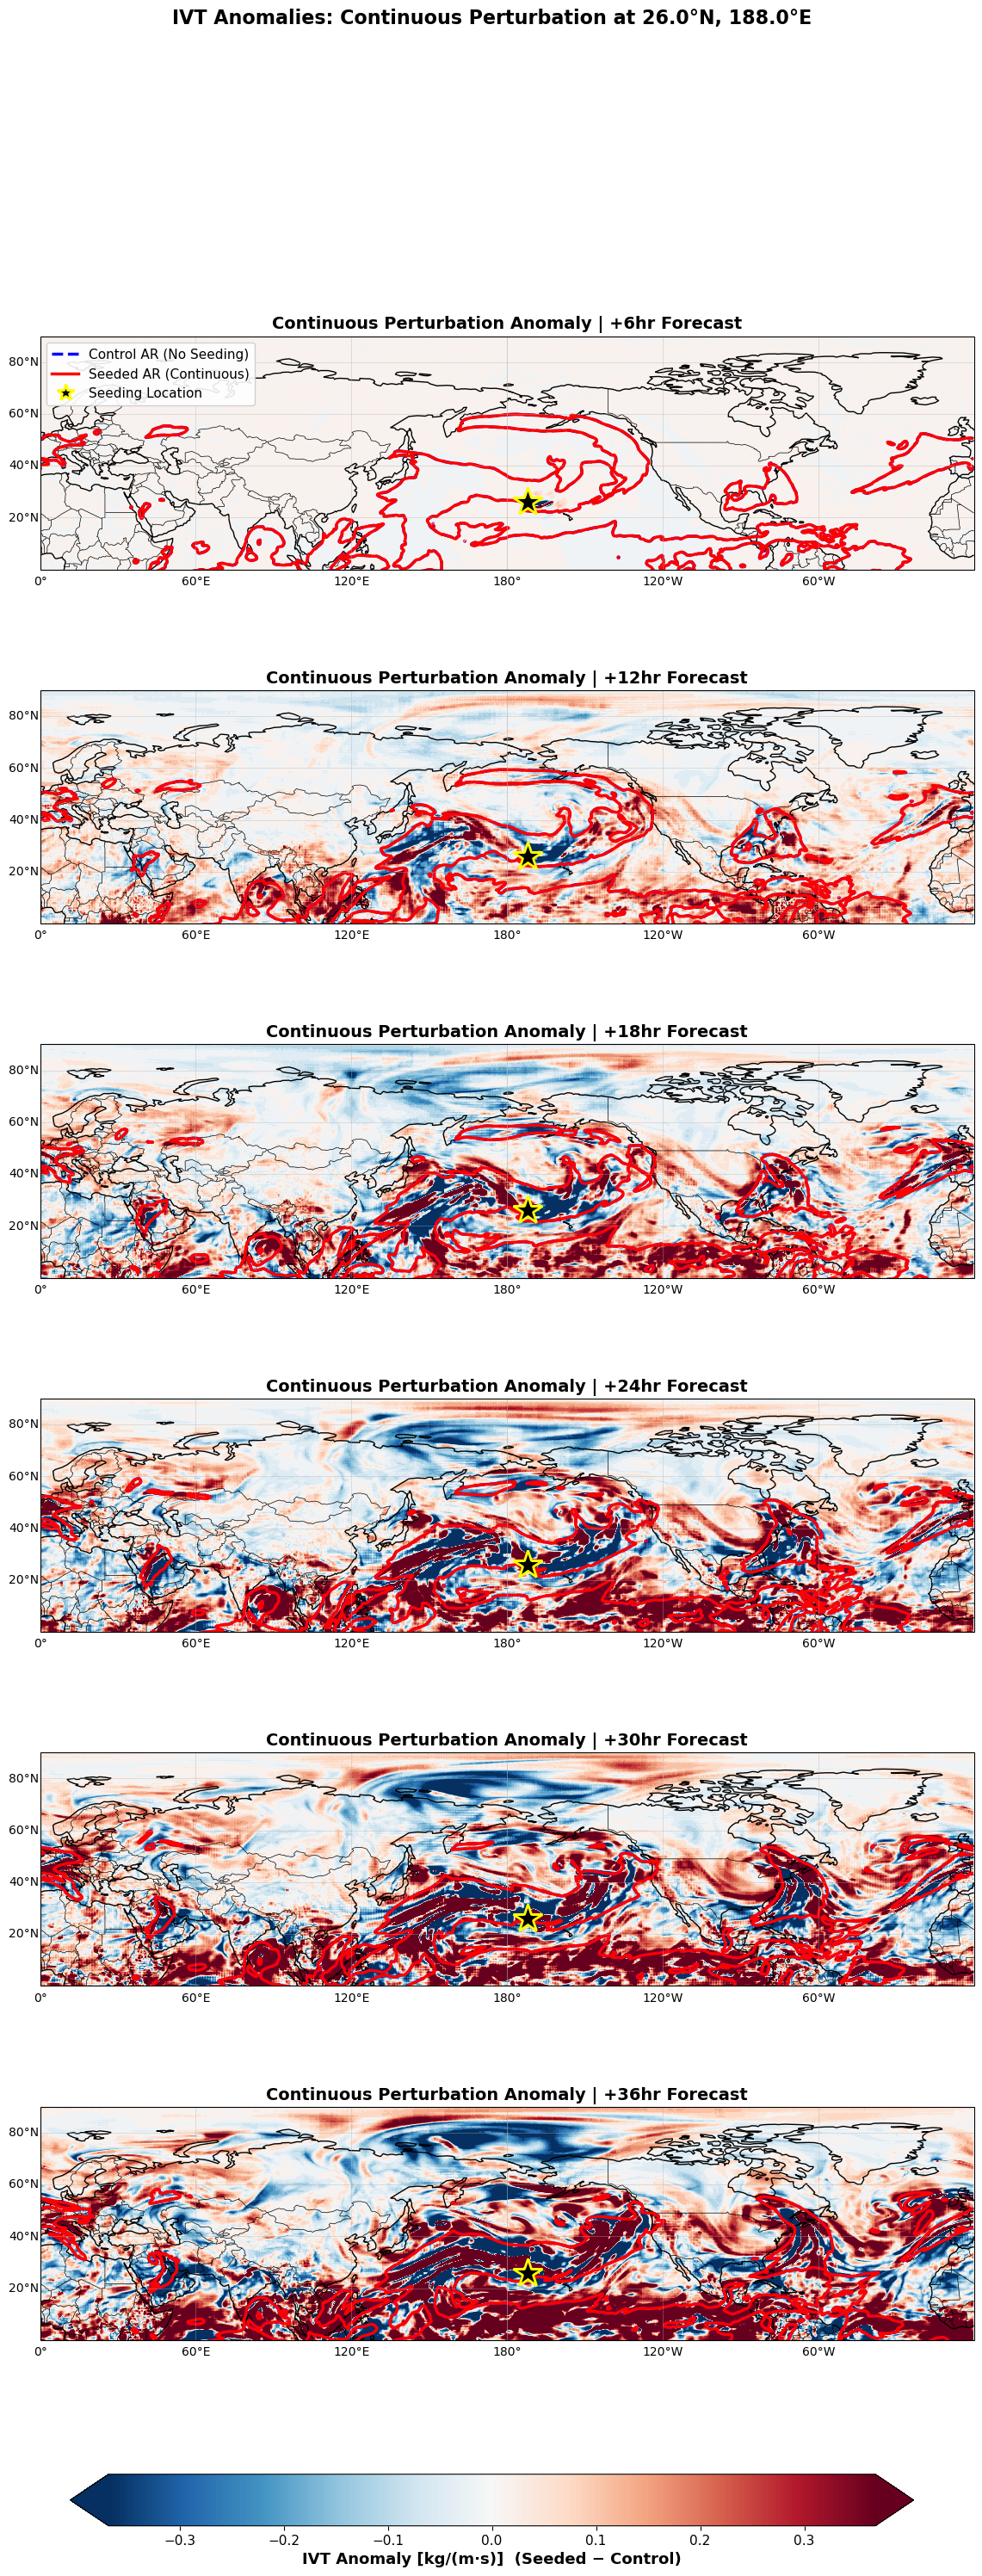

✓ Visualization complete (shared symmetric color scale across all panels)


In [30]:
from matplotlib.cm import ScalarMappable

# --- Settings: choose how to determine the global color limits ---
USE_PERCENTILES = True    # True = robust range (percentiles), False = true extrema
PCT_LOW, PCT_HIGH = 5, 95 # Only used if USE_PERCENTILES

# --- Determine symmetric global colorbar range across ALL panels ---
# Flatten all diffs across time (and drop NaNs)
all_diffs = np.concatenate([np.ravel(x[np.isfinite(x)]) for x in ivt_diff_continuous])

if USE_PERCENTILES:
    vmin = np.percentile(all_diffs, PCT_LOW)
    vmax = np.percentile(all_diffs, PCT_HIGH)
else:
    vmin = np.min(all_diffs)
    vmax = np.max(all_diffs)

amax = max(abs(vmin), abs(vmax))  # symmetric about zero
levels_diff = np.linspace(-amax, amax, 25)

# --- Plot ---
fig, axes = plt.subplots(
    num_steps, 1,
    figsize=(14, 5 * num_steps),
    subplot_kw={'projection': ccrs.PlateCarree(central_longitude=180)}
)

# Ensure axes is iterable
if num_steps == 1:
    axes = [axes]

for t in range(num_steps):
    ax = axes[t]

    # IVT anomaly (Seeded - Control)
    im = ax.contourf(
        lons, lats, ivt_diff_continuous[t],
        levels=levels_diff, cmap='RdBu_r', extend='both',
        transform=ccrs.PlateCarree()
    )

    # Control AR contour (blue dashed) at IVT=250
    ax.contour(
        lons, lats, ivt_control_forecast[t], levels=[250],
        colors='blue', linewidths=2.5, linestyles='--',
        transform=ccrs.PlateCarree()
    )

    # Seeded AR contour (red solid) at IVT=250
    ax.contour(
        lons, lats, ivt_continuous[t], levels=[250],
        colors='red', linewidths=2.5, linestyles='-',
        transform=ccrs.PlateCarree()
    )

    # Seeding location marker
    ax.plot(
        seeding_location['lon_center'], seeding_location['lat_center'],
        marker='*', markersize=25, color='black',
        markeredgecolor='yellow', markeredgewidth=2,
        transform=ccrs.PlateCarree(), zorder=10
    )

    # Map features
    ax.coastlines(linewidth=1)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.3)
    ax.set_extent([-180, 180, 0, 90], crs=ccrs.PlateCarree())

    # Gridlines
    gl = ax.gridlines(draw_labels=True, linewidth=0.5, alpha=0.5)
    gl.top_labels = False
    gl.right_labels = False

    # Title
    hours_ahead = (t + 1) * 6
    ax.set_title(
        f'Continuous Perturbation Anomaly | +{hours_ahead}hr Forecast',
        fontsize=14, fontweight='bold'
    )

    # Legend on first panel
    if t == 0:
        from matplotlib.lines import Line2D
        legend_elements = [
            Line2D([0], [0], color='blue', linestyle='--', linewidth=2.5,
                   label='Control AR (No Seeding)'),
            Line2D([0], [0], color='red', linestyle='-', linewidth=2.5,
                   label='Seeded AR (Continuous)'),
            Line2D([0], [0], marker='*', color='w', markerfacecolor='black',
                   markersize=15, markeredgecolor='yellow', markeredgewidth=2,
                   label='Seeding Location', linestyle='None')
        ]
        ax.legend(handles=legend_elements, loc='upper left', fontsize=11, framealpha=0.9)

# --- Add a global colorbar that matches the shared limits exactly ---
sm = ScalarMappable(cmap='RdBu_r')
sm.set_clim(-amax, amax)  # symmetric actual limits (shared by all panels)

cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.02])
cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', extend='both')
cbar.set_label('IVT Anomaly [kg/(m·s)]  (Seeded − Control)', fontsize=13, fontweight='bold')
cbar.ax.tick_params(labelsize=11)

# --- Figure title and layout ---
plt.suptitle(
    f'IVT Anomalies: Continuous Perturbation at '
    f'{seeding_location["lat_center"]:.1f}°N, {seeding_location["lon_center"]:.1f}°E',
    fontsize=16, fontweight='bold', y=0.995
)
plt.subplots_adjust(bottom=0.08)
plt.show()

print("✓ Visualization complete (shared symmetric color scale across all panels)")

# Grid Perturbation Experiment

Now we'll test perturbations at 64 different locations in the Pacific Ocean to understand which regions are most effective for controlling AR trajectories.

**Grid Configuration:**
- 8×8 grid (64 points total)
- Pacific Ocean upstream of West Coast ARs
- Latitude: 30°N to 50°N
- Longitude: 180°E to 220°E (-180°W to -140°W)
- Same radius (300 km) for each point

In [39]:
# =========================
# ===== USER CONFIG =======
# =========================
# Grid bounding box (must match lons_np convention)
GRID_LAT_MIN = 20.0 # °N
GRID_LAT_MAX = 50.0 # °N
GRID_LON_MIN = 160.0 # °E if using 0–360 (≈ 160E)
GRID_LON_MAX = 230.0 # °E if using 0–360 (≈ 130W)

# Grid resolution
N_LAT = 6
N_LON = 6

# Forecast steps (e.g., 2 → +6 h and +12 h if your model is 6‑hourly)
ROLLOUT_STEPS = 6

# Map extent for plots (in same lon convention as your data)
MAP_EXTENT = [-180, 180, 0, 70] # focus on NH; adjust as desired

# Output folder
OUT_DIR = "./ivt_anomaly_grid_pngs"

# Seeding defaults (radius pulled from your base seeding config); you can override here if needed
SEEDING_RADIUS_KM = 300

In [41]:
# =========================
# ====== HELPERS ==========
# =========================

def _within_bounds(vals, vmin, vmax):
    """Return indices of vals within [vmin, vmax]."""
    vals = np.asarray(vals)
    if vmin > vmax:
        raise ValueError("Grid bounds invalid: min > max")
    return np.where((vals >= vmin) & (vals <= vmax))[0]


def build_centers_in_bounds(lats_np, lons_np, lat_min, lat_max, lon_min, lon_max, n_lat=8, n_lon=8):
    """Pick n_lat × n_lon centers evenly from the subset of lats/lons within bounds."""
    lat_idx_all = _within_bounds(lats_np, lat_min, lat_max)
    lon_idx_all = _within_bounds(lons_np, lon_min, lon_max)
    if len(lat_idx_all) == 0 or len(lon_idx_all) == 0:
        raise ValueError("No grid points found within the specified lat/lon bounds.")

    # Evenly sample indices across the subset
    lat_idx = np.linspace(0, len(lat_idx_all) - 1, n_lat, dtype=int)
    lon_idx = np.linspace(0, len(lon_idx_all) - 1, n_lon, dtype=int)

    centers = []
    for ii in lat_idx:
        for jj in lon_idx:
            centers.append((float(lats_np[lat_idx_all[ii]]), float(lons_np[lon_idx_all[jj]])))
    return centers


def ivt_from_preds(pred_list, pressure_levels):
    """Compute IVT magnitude arrays from a list of model predictions (per step)."""
    out = []
    for pred in pred_list:
        u = pred.atmos_vars["u"][:, 0]
        v = pred.atmos_vars["v"][:, 0]
        q = pred.atmos_vars["q"][:, 0]
        _, _, ivt_mag = calculate_ivt_integrated(u, v, q, pressure_levels)
        out.append(ivt_mag[0].numpy())
    return out


def evaluate_seed_at_location(model, batch_control, lat_c, lon_c,
                              base_seeding_location, seeding_params_realistic,
                              rollout_steps=2):
    """Clone control, apply seeding at (lat_c, lon_c), rollout, and return IVT arrays."""
    device = next(model.parameters()).device

    # Fresh seeded batch
    batch_seeded = Batch(
        surf_vars={k: v.clone() for k, v in batch_control.surf_vars.items()},
        atmos_vars={k: v.clone() for k, v in batch_control.atmos_vars.items()},
        static_vars={k: v.clone() for k, v in batch_control.static_vars.items()},
        metadata=batch_control.metadata
    ).to(device)

    # Mask for this center
    this_loc = dict(base_seeding_location)
    this_loc['lat_center'] = float(lat_c)
    this_loc['lon_center'] = float(lon_c)
    mask_np = create_seeding_mask(lats_np, lons_np, this_loc)

    # Apply physical seeding
    _ = apply_realistic_cloud_seeding(batch_seeded, mask_np, seeding_params_realistic)

    with torch.inference_mode():
        preds_s = [p.to("cpu") for p in rollout(model, batch_seeded, steps=rollout_steps)]

    pressure_levels = batch_control.metadata.atmos_levels
    ivt_s = ivt_from_preds(preds_s, pressure_levels)
    return ivt_s


def save_ivt_anomaly_png(ivt_diff_list, lats_np, lons_np, seeding_loc, out_dir, fname_prefix,
                          title_prefix="Cloud Seeding Experiment: IVT Anomaly Only",
                          map_extent=MAP_EXTENT):
    """Save a single PNG showing ALL steps for one seeding point (Seeded − Control)."""
    os.makedirs(out_dir, exist_ok=True)
    print("📊 Creating IVT anomaly maps (Seeded − Control)...")

    proj = ccrs.PlateCarree(central_longitude=180)
    data_crs = ccrs.PlateCarree()

    lon_grid, lat_grid = np.meshgrid(lons_np, lats_np)
    ivt_diff = [np.array(a, dtype=float) for a in ivt_diff_list]
    n_steps = len(ivt_diff)

    amax = np.nanmax([np.nanmax(np.abs(x)) for x in ivt_diff]) if n_steps > 0 else 0.0
    amax = 1.0 if (not np.isfinite(amax) or amax == 0) else amax
    levels = np.linspace(-amax, amax, 21)

    fig, axes = plt.subplots(n_steps, 1, figsize=(12, max(4.5*n_steps, 5)), subplot_kw={'projection': proj})
    if n_steps == 1:
        axes = np.array([axes])

    neg_lvls = [-300, -200, -100, -50]
    pos_lvls = [50, 100, 200, 300]

    from cartopy.geodesic import Geodesic
    def plot_geodesic_ring(ax, lon, lat, radius_km, n=180, **kwargs):
        g = Geodesic()
        poly = g.circle(lon=lon, lat=lat, radius=radius_km*1000.0, n_samples=n)
        xs, ys = zip(*poly)
        ax.plot(xs, ys, transform=ccrs.Geodetic(), **kwargs)

    for idx in range(n_steps):
        hours = (idx+1)*6  # adjust if your model’s step != 6 h
        ax = axes[idx]

        # Base map
        ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.4, zorder=1)
        ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.25, zorder=0)
        ax.add_feature(cfeature.COASTLINE, linewidth=1.2, edgecolor='black', zorder=4)
        ax.add_feature(cfeature.BORDERS, linewidth=0.6, edgecolor='gray', alpha=0.5, zorder=4)
        ax.set_extent(map_extent, crs=data_crs)

        diff = ivt_diff[idx]
        ax.contourf(lon_grid, lat_grid, diff, levels=levels, cmap='RdBu_r', extend='both',
                    transform=data_crs, alpha=0.9, zorder=2)

        # Optional emphasized contours
        if np.isfinite(np.nanmin(diff)) and (np.nanmin(diff) < min(neg_lvls)):
            cs_neg = ax.contour(lon_grid, lat_grid, diff, levels=neg_lvls, colors='blue', linewidths=1.8,
                                linestyles='--', transform=data_crs, zorder=5)
            ax.clabel(cs_neg, inline=True, fontsize=9, fmt='%d')
        if np.isfinite(np.nanmax(diff)) and (np.nanmax(diff) > max(pos_lvls)):
            cs_pos = ax.contour(lon_grid, lat_grid, diff, levels=pos_lvls, colors='red', linewidths=1.8,
                                linestyles='-', transform=data_crs, zorder=5)
            ax.clabel(cs_pos, inline=True, fontsize=9, fmt='+%d')

        # Seeding context (first panel only)
        if idx == 0:
            ax.plot(seeding_loc['lon_center'], seeding_loc['lat_center'], marker='*', markersize=18,
                    color='k', transform=data_crs, zorder=10)
            plot_geodesic_ring(ax, seeding_loc['lon_center'], seeding_loc['lat_center'],
                               seeding_loc.get('radius_km', SEEDING_RADIUS_KM),
                               linewidth=2.0, linestyle=':', color='k')

        max_abs = np.nanmax(np.abs(diff)) if np.size(diff) else np.nan
        ax.set_title(f'IVT Anomaly (Seeded − Control) | +{hours} hr | Max |Δ|: '
                     f"{(0.0 if not np.isfinite(max_abs) else max_abs):.0f} kg/(m·s)",
                     fontsize=14, fontweight='bold', pad=8)

    # Shared colorbar
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize
    sm = ScalarMappable(norm=Normalize(vmin=-amax, vmax=amax), cmap='RdBu_r')
    sm.set_array([])
    cbar_ax = fig.add_axes([0.15, 0.02, 0.7, 0.018])
    cbar = fig.colorbar(sm, cax=cbar_ax, orientation='horizontal', extend='both')
    cbar.set_label('IVT Anomaly [kg/(m·s)]  (Seeded − Control)', fontsize=13, fontweight='bold')
    cbar.ax.tick_params(labelsize=11)

    plt.suptitle(f'{title_prefix}(Red = increase, Blue = decrease)', fontsize=17, fontweight='bold', y=0.995)
    plt.tight_layout(rect=[0, 0.04, 1, 0.99])

    out_path = os.path.join(out_dir, f"{fname_prefix}.png")
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f"✅ Saved IVT anomaly PNG: {out_path}")

# =========================
# ======= OVERVIEW ========
# =========================

def save_seeding_centers_overview(centers, lats_np, lons_np, out_dir, fname="seed_centers_overview.png",
                                   lat_min=GRID_LAT_MIN, lat_max=GRID_LAT_MAX,
                                   lon_min=GRID_LON_MIN, lon_max=GRID_LON_MAX,
                                   map_extent=MAP_EXTENT, draw_rings=False, label_points=True,
                                   ring_radius_km=SEEDING_RADIUS_KM):
    """Save a single PNG showing all seeding centers and the user-defined bounds box."""
    os.makedirs(out_dir, exist_ok=True)

    proj = ccrs.PlateCarree(central_longitude=180)
    data_crs = ccrs.PlateCarree()

    fig = plt.figure(figsize=(13, 6.5))
    ax = plt.axes(projection=proj)

    # Base map
    ax.add_feature(cfeature.LAND, facecolor='lightgray', alpha=0.4, zorder=1)
    ax.add_feature(cfeature.OCEAN, facecolor='lightblue', alpha=0.25, zorder=0)
    ax.add_feature(cfeature.COASTLINE, linewidth=1.0, edgecolor='black', zorder=3)
    ax.add_feature(cfeature.BORDERS, linewidth=0.5, edgecolor='gray', alpha=0.6, zorder=3)
    ax.set_extent(map_extent, crs=data_crs)

    # Draw user-defined bounds box
    box_x = [lon_min, lon_max, lon_max, lon_min, lon_min]
    box_y = [lat_min, lat_min, lat_max, lat_max, lat_min]
    ax.plot(box_x, box_y, transform=data_crs, color='k', linewidth=1.5, linestyle='--', zorder=4)

    # Plot centers
    lats_c = [lt for lt, ln in centers]
    lons_c = [ln for lt, ln in centers]
    ax.scatter(lons_c, lats_c, s=24, marker='o', color='crimson', edgecolors='white', linewidths=0.6,
               transform=data_crs, zorder=5)

    # Optional geodesic rings (can get busy with many points)
    if draw_rings:
        from cartopy.geodesic import Geodesic
        g = Geodesic()
        for (lt, ln) in centers:
            poly = g.circle(lon=ln, lat=lt, radius=ring_radius_km*1000.0, n_samples=120)
            xs, ys = zip(*poly)
            ax.plot(xs, ys, transform=ccrs.Geodetic(), color='crimson', linewidth=0.6, alpha=0.55, zorder=4)

    # Labels
    if label_points:
        for k, (lt, ln) in enumerate(centers):
            ax.text(ln, lt, f"{k+1}", transform=data_crs, fontsize=7, ha='center', va='center',
                    color='white', path_effects=[], zorder=6)

    ax.set_title(f"Seeding Centers Overview ({len(centers)} pts)\n"
                 f"Bounds: {lat_min}–{lat_max}°N, {lon_min}–{lon_max} lon",
                 fontsize=14, fontweight='bold', pad=8)

    out_path = os.path.join(out_dir, fname)
    plt.savefig(out_path, dpi=180, bbox_inches='tight')
    plt.close(fig)
    print(f"🗺️ Saved seeding centers overview: {out_path}")

In [46]:
# =========================
# ========= MAIN ==========
# =========================

# Ensure model is on device
if next(model.parameters()).device.type == 'cpu':
    model = model.to('cuda')

os.makedirs(OUT_DIR, exist_ok=True)

# Build grid centers inside custom bounds
centers = build_centers_in_bounds(
    lats_np, lons_np,
    lat_min=GRID_LAT_MIN, lat_max=GRID_LAT_MAX,
    lon_min=GRID_LON_MIN, lon_max=GRID_LON_MAX,
    n_lat=N_LAT, n_lon=N_LON
)
print(f"🧭 Grid centers: {len(centers)} points in bounds [{GRID_LAT_MIN},{GRID_LAT_MAX}]N × [{GRID_LON_MIN},{GRID_LON_MAX}] lon")

# >>> NEW: Save an overview map with all seeding centers <<<
save_seeding_centers_overview(
    centers=centers,
    lats_np=lats_np,
    lons_np=lons_np,
    out_dir=OUT_DIR,
    fname="seed_centers_overview.png",
    lat_min=GRID_LAT_MIN, lat_max=GRID_LAT_MAX,
    lon_min=GRID_LON_MIN, lon_max=GRID_LON_MAX,
    map_extent=MAP_EXTENT,
    draw_rings=False,        # set True to draw a ring at each center
    label_points=True,       # set False to hide numeric labels
    ring_radius_km=SEEDING_RADIUS_KM
)

# Cache control predictions ONCE (for speed & comparability)
with torch.inference_mode():
    preds_control = [p.to('cpu') for p in rollout(model, batch_control, steps=ROLLOUT_STEPS)]
pressure_levels = batch_control.metadata.atmos_levels
ivt_control_list = ivt_from_preds(preds_control, pressure_levels)

# Run seeding experiments & save per‑point PNG
for idx, (lat_c, lon_c) in enumerate(centers):
    print(f"▶ Running seeding for point {idx+1}/{len(centers)}: lat={lat_c:.2f}, lon={lon_c:.2f}")

    # Seeded IVT
    ivt_seeded_list = evaluate_seed_at_location(
        model=model,
        batch_control=batch_control,
        lat_c=lat_c,
        lon_c=lon_c,
        base_seeding_location={'lat_center': lat_c, 'lon_center': lon_c, 'radius_km': SEEDING_RADIUS_KM},
        seeding_params_realistic=seeding_params_realistic,
        rollout_steps=ROLLOUT_STEPS
    )

    # ΔIVT per step
    ivt_diff_list = [s - c for s, c in zip(ivt_seeded_list, ivt_control_list)]

    # Save figure
    fname_prefix = f"seed_{idx:02d}_lat{lat_c:.2f}_lon{lon_c:.2f}_steps{ROLLOUT_STEPS}"
    save_ivt_anomaly_png(
        ivt_diff_list=ivt_diff_list,
        lats_np=lats_np,
        lons_np=lons_np,
        seeding_loc={'lat_center': float(lat_c), 'lon_center': float(lon_c), 'radius_km': SEEDING_RADIUS_KM},
        out_dir=OUT_DIR,
        fname_prefix=fname_prefix,
        title_prefix=f"Cloud Seeding IVT Anomaly (Grid within {GRID_LAT_MIN}–{GRID_LAT_MAX}°N, {GRID_LON_MIN}–{GRID_LON_MAX} lon)",
        map_extent=MAP_EXTENT
    )

print("✅ All grid-point PNGs saved.")

🧭 Grid centers: 36 points in bounds [20.0,50.0]N × [160.0,230.0] lon
🗺️ Saved seeding centers overview: ./ivt_anomaly_grid_pngs/seed_centers_overview.png
▶ Running seeding for point 1/36: lat=50.00, lon=160.00
📊 Creating IVT anomaly maps (Seeded − Control)...


/tmp/ipykernel_1445491/1501397723.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.99])


✅ Saved IVT anomaly PNG: ./ivt_anomaly_grid_pngs/seed_00_lat50.00_lon160.00_steps6.png
▶ Running seeding for point 2/36: lat=50.00, lon=174.00
📊 Creating IVT anomaly maps (Seeded − Control)...


/tmp/ipykernel_1445491/1501397723.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.99])


✅ Saved IVT anomaly PNG: ./ivt_anomaly_grid_pngs/seed_01_lat50.00_lon174.00_steps6.png
▶ Running seeding for point 3/36: lat=50.00, lon=188.00
📊 Creating IVT anomaly maps (Seeded − Control)...


...

✅ Saved IVT anomaly PNG: ./ivt_anomaly_grid_pngs/seed_33_lat20.00_lon202.00_steps6.png
▶ Running seeding for point 35/36: lat=20.00, lon=216.00
📊 Creating IVT anomaly maps (Seeded − Control)...


/tmp/ipykernel_1445491/1501397723.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.99])


✅ Saved IVT anomaly PNG: ./ivt_anomaly_grid_pngs/seed_34_lat20.00_lon216.00_steps6.png
▶ Running seeding for point 36/36: lat=20.00, lon=230.00
📊 Creating IVT anomaly maps (Seeded − Control)...


/tmp/ipykernel_1445491/1501397723.py:155: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0.04, 1, 0.99])


✅ Saved IVT anomaly PNG: ./ivt_anomaly_grid_pngs/seed_35_lat20.00_lon230.00_steps6.png
✅ All grid-point PNGs saved.
